In [ ]:
!pip install faiss-cpu rank-bm25 transformers torch tiktoken
!pip install spacy && python -m spacy download ru_core_news_sm
!pip install python-docx networkx numpy
!pip install -U safetensors accelerate huggingface_hub sentencepiece protobuf
!pip install -U torch torchvision torchaudio

  Using cached faiss_cpu-1.13.2-cp310-abi3-macosx_14_0_arm64.whl.metadata (7.6 kB)
  Using cached rank_bm25-0.2.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached transformers-5.1.0-py3-none-any.whl.metadata (31 kB)
  Using cached torch-2.10.0-2-cp311-none-macosx_11_0_arm64.whl.metadata (31 kB)
  Using cached numpy-2.4.2-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached huggingface_hub-1.4.1-py3-none-any.whl.metadata (13 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached regex-2026.1.15-cp311-cp311-macosx_11_0_arm64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typer_slim-0.23.1-py3-none-any.whl.metadata (4.2 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached filelock-3.24.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.2.0

In [ ]:
!pip install -U huggingface_hub transformers

In [2]:
!hf download yandex/YandexGPT-5-Lite-8B-instruct --local-dir ./models/YandexGPT-5-Lite-8B-instruct

Fetching 13 files: 100%|████████████████████████| 13/13 [19:20<00:00, 89.30s/it]
Download complete: : 16.1GB [19:20, 103MB/s]              /Users/evexponencial/Downloads/NLP_dipplom/models/YandexGPT-5-Lite-8B-instruct
Download complete: : 16.1GB [19:20, 13.8MB/s]


In [ ]:
!pip uninstall -y faiss-cpu
!pip install -U hnswlib

# !pip uninstall -y hnswlib
# !pip install -U faiss-cpu

In [1]:
import os
import sys
import re
import json
import uuid
import math
import uuid
import pickle
import zipfile
import difflib
import unicodedata
from enum import Enum
import datetime as dt
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from rank_bm25 import BM25Okapi
from transformers.tokenization_utils_base import BatchEncoding
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from transformers import AutoModelForCausalLM
import torch, safetensors, sentencepiece

from docx import Document as Docx
from docx.table import Table
from docx.text.paragraph import Paragraph
from docx.oxml.text.paragraph import CT_P
from docx.oxml.table import CT_Tbl

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

torch.set_num_threads(1)

print(sentencepiece.__version__)
print(sys.executable)
print("safetensors:", safetensors.__version__)

/Users/evexponencial/Downloads/NLP_dipplom/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.2.1
/Users/evexponencial/Downloads/NLP_dipplom/.venv/bin/python
safetensors: 0.7.0


In [2]:
# для MacBook вместо FAISS используем HNSW
try:
    import faiss  # noqa: F401
    FAISS_AVAILABLE = True
    HNSW_AVAILABLE = False
    print("faiss доступен, используем его для векторного поиска")
except Exception as e:
    import hnswlib
    HNSW_AVAILABLE = True
    FAISS_AVAILABLE = False
    print("faiss недоступен, используем hnswlib, потому что есть ошибка импорта:", type(e).__name__, e)

try:
    import spacy, subprocess, sys
    spacy.load("ru_core_news_sm")
    print("spaCy модель ru_core_news_sm доступна")
except Exception:
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "ru_core_news_sm"])
    print("ru_core_news_sm скачан и доступен")

def pick_device(device):
  """Выбирает лучшее устройство: cuda, mps, cpu"""
  if device:
    return device
  if torch.cuda.is_available():
    return "cuda"
  if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    return "mps"
  return "cpu"

def _load_spacy(cfg):
  if spacy is None:
    return None
  try:
    return spacy.load(cfg.spacy_model)
  except Exception:
    return None

print(FAISS_AVAILABLE, HNSW_AVAILABLE)

faiss недоступен, используем hnswlib, потому что есть ошибка импорта: ModuleNotFoundError No module named 'faiss'
spaCy модель ru_core_news_sm доступна
False True


In [3]:
# Logger
class JSONLLogger:
  def __init__(self, path):
    self.path = path
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)

  def log(self, record):
    record = dict(record)
    record["ts"] = dt.datetime.now().isoformat()
    with open(self.path, "a", encoding="utf-8") as f:
      f.write(json.dumps(record, ensure_ascii=False) + "\n")

@dataclass
class Chunk:
  id: str
  doc_id: str
  title: str
  text: str
  meta: Dict[str, Any] = field(default_factory=dict)

@dataclass
class RAGConfig:
  # chunking
  max_chunk_chars: int = 1400
  chunk_overlap_chars: int = 150 # overlap для параграфов (не таблиц)
  table_row_block_size: int = 15
  keep_table_header: bool = True

  # метаданные документа (из титульного листа)
  doc_meta_head_paragraphs: int = 90

  # embeddings / retrieval
  embed_model_name: str = "intfloat/multilingual-e5-base"
  faiss_batch_size: int = 32
  hybrid_rrf_k: int = 60

  # reranking
  use_reranker: bool = False
  reranker_model_name: str = "BAAI/bge-reranker-v2-m3"
  reranker_top_k: int = 30

  # graph/entities
  spacy_model: str = "ru_core_news_sm"
  entity_min_df: int = 2
  entity_max_df_ratio: float = 0.20 # > 20% чанков => шум
  max_entities_per_chunk: int = 30 # по idf
  entity_min_len: int = 3

  # scoring tweaks
  boost_tables: bool = True
  table_boost: float = 0.25

  # logging
  log_jsonl_path: Optional[str] = None

In [4]:
_WORD_RE = re.compile(r"[A-Za-zА-Яа-яЁё0-9]+(?:[-_][A-Za-zА-Яа-яЁё0-9]+)*", re.UNICODE)
_COMP_CODE_RE = re.compile(r"\b(УК|ОПК|ПК)\s*-\s*\d+(?:\.\d+)?\b", re.IGNORECASE)

RU_STOPWORDS = {
  # базовые русские стоп-слова (укороченный список; можно расширять)
  "и","в","во","на","по","с","со","к","ко","о","об","от","до","из","за","у","для","при","это","то","а","но",
  "как","так","же","не","ни","или","ли","бы","что","чтобы","который","которая","которые","которых","этот","эта",
  "эти","этих","тот","та","те","тех","его","ее","их","мы","вы","они","я","ты","он","она","оно",
  "будет","есть","является","являются","являться","может","могут","должен","должны","следует","необходимо",
  "данных","данные","работа","работы","обучение","обучения","таблица","таблицы","рисунок","рисунки","раздел","разделы",
  "цель","цели","задача","задачи","тема","темы","дисциплина","дисциплины","программа","программы"
}
EN_STOPWORDS = {"the","a","an","and","or","to","of","in","on","for","is","are","was","were","be","been","with","by"}
DOMAIN_STOPWORDS = {
  # шумные доменные слова — часто встречаются и мало помогают графу
  "студент","студенты","обучающийся","обучающиеся","семестр","час","часов","зачет","экзамен",
  "лекция","лекции","практика","практические","самостоятельная","работа","работы"
}

def normalize_text(text):
  text = text.replace("\u00a0", " ")
  text = re.sub(r"[ \t]+", " ", text)
  text = re.sub(r"\n{3,}", "\n\n", text)
  return text.strip()

def tokenize(text):
  tokens = [t.lower() for t in _WORD_RE.findall(text)]
  return tokens

In [5]:
# Итератор блоков текста (параграфы и таблицы) в документе
def iter_block_items(doc):
  """Итерирует (тип, объект) по порядку в DOCX:
  - ('p', Paragraph)
  - ('t', Table)
  """
  parent = doc.element.body
  for child in parent.iterchildren():
    if isinstance(child, CT_P):
      yield ("p", Paragraph(child, doc))
    elif isinstance(child, CT_Tbl):
      yield ("t", Table(child, doc))

def _is_toc_paragraph(p):
  """DOCX-оглавление часто имеет стиль TOC*"""
  name = ""
  try:
    name = (p.style.name or "")
  except Exception:
    name = ""
  return name.strip().lower().startswith("toc")

def _is_heading_paragraph(p):
  """DOCX-заголовок по стилю (Heading/Заголовок)"""
  name = ""
  try:
    name = (p.style.name or "")
  except Exception:
    name = ""
  name_l = name.strip().lower()
  return name_l.startswith("heading") or name_l.startswith("заголовок")

# Детекция заголовков
# Не завязываемся только на стили DOCX, но и НЕ объявляем заголовком всё, что начинается с "1."
# Поэтому используем:
# 1) строгую нумерацию раздела: 5.1. ... (обязательно точка после номера) => не ловим даты 22.12.2022
# 2) белый список типовых заголовков РПД/практик
# 3) семантические якоря (подстроки), если белый список не сработал
# 4) анти-фильтры: оглавление (лидеры .... 12), страницы, т.п.

_STYLE_LEVEL_RE = re.compile(r"(heading|заголовок)\s*(\d+)", re.I)

# Нумерация раздела/подраздела: "4. ...", "5.1. ...", "6.2.1. ..."
# Требуем точку ПОСЛЕ последнего сегмента
_NUM_HEADING_RE = re.compile(r"^\s*(\d{1,2}(?:\.\d{1,2}){0,3})\.(?!\d)\s*(\S.*)$")
# Мягкий вариант: допускаем отсутствие завершающей точки (например, '5.1 Учебно-...'),
# но только для нумерации не глубже 2 уровней (иначе рискуем поймать коды/даты).
_NUM_HEADING_RE_SOFT = re.compile(r"^\s*(\d{1,2}(?:\.\d{1,2}){0,1})(?!\.)\s+(\S.*)$")

# Оглавление в тексте: лидеры "...." или "……" + номер страницы в конце
_TOC_LIKE_RE = re.compile(r"(\.{3,}|…{3,}|·{3,})\s*\d+\s*$")

def _norm_heading_text(s):
  s = normalize_text(s or "")
  s = s.replace("ё", "е").lower()
  # нормализуем разные тире/дефисы
  s = s.replace("–", "-").replace("—", "-")
  s = s.replace("«", """).replace("»", """).replace("“", """).replace("”", """)
  s = re.sub(r"\s+", " ", s).strip()
  # убираем хвостовую пунктуацию
  s = s.strip(" ,;:.-")
  return s

# Типовые заголовки РПД дисциплин
_CANON_DISCIPLINE_HEADINGS = [
  "1. Наименование дисциплины",
  "2. Перечень планируемых результатов освоения образовательной программы (перечень компетенций) с указанием индикаторов их достижения и планируемых результатов обучения по дисциплине",
  "3. Место дисциплины в структуре образовательной программы",
  "4. Объем дисциплины (модуля) в зачетных единицах и в академических часах с выделением объема аудиторной (лекции, семинары) и самостоятельной работы обучающихся",
  "5. Содержание дисциплины, структурированное по темам (разделам) дисциплины с указанием их объемов (в академических часах) и видов учебных занятий",
  "5.1. Содержание дисциплины",
  "5.2. Учебно–тематический план",
  "5.3. Содержание семинаров, практических занятий",
  "6. Перечень учебно-методического обеспечения для самостоятельной работы обучающихся по дисциплине",
  "6.1. Перечень вопросов, отводимых на самостоятельное освоение дисциплины, формы внеаудиторной самостоятельной работы",
  "6.2. Перечень вопросов, заданий, тем для подготовки к текущему контролю",
  "7. Фонд оценочных средств для проведения промежуточной аттестации обучающихся по дисциплине",
  "8. Перечень основной и дополнительной учебной литературы, необходимой для освоения дисциплины",
  "9. Перечень ресурсов информационно-телекоммуникационной сети «Интернет», необходимых для освоения дисциплины",
  "10. Методические указания для обучающихся по освоению дисциплины",
  "11. Перечень информационных технологий, используемых при осуществлении образовательного процесса по дисциплине, включая перечень необходимого программного обеспечения и информационных справочных систем",
  "12. Описание материально-технической базы, необходимой для осуществления образовательного процесса по дисциплине",
]

# Типовые заголовки программ практик
_CANON_PRACTICE_HEADINGS = [
  "1. Наименование вида и типов практики, способа и формы (форм) ее проведения",
  "2. Цели и задачи практики",
  "3. Перечень планируемых результатов освоения образовательной программы (перечень компетенций) с указанием индикаторов их достижения и планируемых результатов обучения при прохождении практики",
  "4. Место практики в структуре образовательной программы",
  "5. Объём практики в зачетных единицах и ее продолжительностьв неделях либо в академических часах",
  "6. Содержание практики",
  "7. Формы отчетности  по практике",
  "8. Фонд оценочных средств для проведения промежуточной аттестации обучающихся по практике",
  "9. Перечень учебной литературы и ресурсов сети «Интернет», необходимых для проведения практики",
  "10. Перечень информационных технологий, используемых при проведении практики, включая перечень необходимого программного обеспечения и информационных справочных систем",
  "11. Описание материально- технической базы, необходимой для проведения практики",
]

# Нормализованные версии для быстрого сравнения
_CANON_DISCIPLINE_HEADINGS_N = [_norm_heading_text(x) for x in _CANON_DISCIPLINE_HEADINGS]
_CANON_PRACTICE_HEADINGS_N = [_norm_heading_text(x) for x in _CANON_PRACTICE_HEADINGS]

# Семантические якоря: если заголовок не совпал с белым списком, но содержит характерные фразы РПД,
# мы всё равно примем его как заголовок (это повышает recall при вариативности формулировок).
_ANCHORS = [
  "наименование дисциплины",
  "перечень планируемых результатов",
  "перечень компетенц",
  "место дисциплины",
  "объем дисциплины",
  "объём дисциплины",
  "трудоемк",
  "трудоёмк",
  "содержание дисциплины",
  "учебно-тематический план",
  "учебно тематический план",
  "содержание семинаров",
  "практических занятий",
  "перечень учебно-методического",
  "фонд оценочных средств",
  "перечень основной и дополнительной",
  "перечень ресурсов",
  "интернет",
  "методические указания",
  "перечень информационных технологий",
  "материально-технической базы",
  # практика
  "цели и задачи практики",
  "место практики",
  "объем практики",
  "объём практики",
  "содержание практики",
  "формы отчетности",
]

def _is_toc_like_text(t):
  t = (t or "").strip()
  if not t:
    return False
  return bool(_TOC_LIKE_RE.search(t))

def detect_heading(txt, style_name="", doc_kind=""):
  """Возвращает (level, heading_text) или None.

  level: 1 для '4. ...', 2 для '5.1. ...', 3 для '5.1.1 ...' и т.д.

  doc_kind: 'discipline' | 'practice' | '' — влияет на белый список заголовков.
  """
  t_raw = normalize_text(txt or "")
  if not t_raw:
    return None

  # Отсеиваем «оглавление-подобные» строки
  if _is_toc_like_text(t_raw):
    return None

  t_norm = _norm_heading_text(t_raw)

  # Попытка по строгой нумерации
  m = _NUM_HEADING_RE.match(t_raw)
  if m:
    num = m.group(1)
    title = m.group(2).strip()
    # нормализованный "номер. заголовок"
    candidate_full = f"{num}. {title}"
    cand_norm = _norm_heading_text(candidate_full)

    # Выбираем соответствующий белый список
    canon = _CANON_PRACTICE_HEADINGS_N if (doc_kind or "").lower().startswith("practice") else _CANON_DISCIPLINE_HEADINGS_N

    # точное/префиксное совпадение с белым списком
    if any(cand_norm.startswith(h) or h.startswith(cand_norm) for h in canon):
      level = num.count(".") + 1
      return (level, candidate_full)

    # семантические якоря (чтобы ловить варианты формулировок)
    if any(a in cand_norm for a in _ANCHORS):
      level = num.count(".") + 1
      return (level, candidate_full)

    # иначе: это скорее пункт списка (например, "10. Создать процесс ..."), а не раздел РПД
    return None


  # Мягкая нумерация (без завершающей точки): '5.1 Учебно‑тематический план'
  m = _NUM_HEADING_RE_SOFT.match(t_raw)
  if m:
    num = m.group(1)
    title = m.group(2).strip()
    candidate_full = f"{num}. {title}"  # нормализуем как будто точка была
    cand_norm = _norm_heading_text(candidate_full)

    canon = _CANON_PRACTICE_HEADINGS_N if (doc_kind or "").lower().startswith("practice") else _CANON_DISCIPLINE_HEADINGS_N

    if any(cand_norm.startswith(h) or h.startswith(cand_norm) for h in canon):
      level = num.count(".") + 1
      return (level, candidate_full)

    if any(a in cand_norm for a in _ANCHORS):
      level = num.count(".") + 1
      return (level, candidate_full)

    return None

  # Если стиль был заголовком (Heading/Заголовок), но нумерации нет
  # Считаем заголовком, если есть смысловой якорь или это короткий "титульный" заголовок.
  lvl = None
  sn = (style_name or "").strip()
  m2 = _STYLE_LEVEL_RE.search(sn)
  if m2:
    try:
      lvl = int(m2.group(2))
    except Exception:
      lvl = None

  if lvl is not None:
    # если оглавление или мусор — уже отсеяли; теперь проверяем смысл
    if any(a in t_norm for a in _ANCHORS) or len(t_norm) <= 80:
      return (max(1, min(lvl, 4)), t_raw)

  return None

In [6]:
def table_to_rows(tbl):
  rows = []
  for r in tbl.rows:
    row = []
    for c in r.cells:
      row.append(normalize_text(c.text or ""))
    # не добавляем полностью пустые строки
    if any(cell for cell in row):
      rows.append(row)
  return rows

def format_table_block(rows):
  # простая табличная сериализация TSV
  return "\n".join(["\t".join(r).strip() for r in rows if any(r)]).strip()

In [7]:
# Метаданные документа РПД
# У многих РПД ключевая информация (направление, ОП, год, тип документа) находится на титульной странице и не повторяется в каждом разделе
# Так гибридный поиск будет работать стабильнее:
# - фильтрация по направлению/году
# - различение "практика" (учебная/производственная) vs "практические занятия"
# - точнее doc routing для program-level вопросов

@dataclass
class DocMeta:
  doc_id: str
  doc_kind: str = "discipline"      # РПД или программа практики
  practice_kind: str = ""           # учебная | производственная | ""
  discipline_name: str = ""         # название дисциплины / практики
  direction_code: str = ""          # код направления - 09.03.03
  direction_name: str = ""          # Прикладная информатика / Программная инженерия
  op_name: str = ""                 # название ОП/профиля, если есть
  university: str = ""
  faculty: str = ""
  department: str = ""
  doc_year: int = 0                 # год с титульного листа

# Регулярки для титульника
_DIR_LINE_RE = re.compile(r"\b(\d{2}\.\d{2}\.\d{2})\s*[-—–]\s*([^\n\r]+)", re.I)
_DIR_LINE2_RE = re.compile(r"направлен\w*\s+подготовк\w*\s*[:\-]?\s*(\d{2}\.\d{2}\.\d{2})\s*[-—–]?\s*([^\n\r]+)", re.I)
_OP_RE = re.compile(r"\bОП\s*[«\"'](.{2,160}?)[»\"']", re.I)
_OP2_LINE_RE = re.compile(r"\bнаправленност\w*\s+программ\w*\s*:\s*(.*)$", re.I)
_QUOTED_RE = re.compile(r"[«\"\'](.{2,200}?)[»\"\']", re.I)
_CITY_YEAR_RE = re.compile(r"\b(Москва|Казань|Санкт-Петербург|Екатеринбург|Новосибирск|Нижний Новгород|Самара|Уфа|Пермь|Ростов-на-Дону)\b[^\n\r]{0,40}?\b((?:19|20)\d{2})\b", re.I)
_YEAR_RE = re.compile(r"\b((?:19|20)\d{2})\b")

def _clean_line(s):
  s = (s or "").strip()
  s = re.sub(r"\s+", " ", s)
  return s.strip()

def extract_doc_meta_from_docx(doc, doc_id, head_n=90):
  """Извлекает метаданные из первых head_n абзацев DOCX (титульный лист + шапка)."""
  pars = [_clean_line(p.text) for p in doc.paragraphs[:head_n] if _clean_line(p.text)]
  head = "\n".join(pars)

  m = DocMeta(doc_id=doc_id)

  # Университет/подразделения
  for p in pars[:35]:
    pl = p.lower().replace("ё", "е")
    if ("университет" in pl or "федеральное государственное" in pl) and not m.university:
      m.university = p
    if "факульт" in pl and not m.faculty:
      m.faculty = p
    if pl.startswith("департамент") and not m.department:
      m.department = p

  # Тип документа: дисциплина или практика (учебная/производственная)
  low = head.lower().replace("ё", "е")
  if re.search(r"\bпрограмма\s+производственн\w*\s+практик", low, re.I):
    m.doc_kind = "practice"
    m.practice_kind = "производственная"
  elif re.search(r"\bпрограмма\s+учебн\w*\s+практик", low, re.I):
    m.doc_kind = "practice"
    m.practice_kind = "учебная"
  elif re.search(r"\bрабочая\s+программа\s+практик", low, re.I):
    m.doc_kind = "practice"

  # Направление: код + название
  mm = _DIR_LINE_RE.search(head) or _DIR_LINE2_RE.search(head)
  if mm:
    m.direction_code = _clean_line(mm.group(1))
    name = _clean_line(mm.group(2))
    # нормализуем: убираем хвостовую пунктуацию, кавычки, запятые
    name = name.strip("«»\"' ,;:.")
    name = name.split(",")[0].strip()
    m.direction_name = name

  # ОП/профиль
  mm = _OP_RE.search(head)
  if mm:
    m.op_name = _clean_line(mm.group(1))

  # Альтернативный вариант: "Направленность программы:" (часто название идёт в кавычках в этой же строке или в следующем абзаце)
  if not m.op_name:
    for i, p in enumerate(pars[:80]):
      if "направленност" in p.lower().replace("ё","е") and "программ" in p.lower().replace("ё","е"):
        m2 = _QUOTED_RE.search(p)
        if m2:
          m.op_name = _clean_line(m2.group(1))
          break
        # иначе пробуем хвост строки после двоеточия
        mline = _OP2_LINE_RE.search(p)
        if mline:
          tail = _clean_line(mline.group(1))
          m3 = _QUOTED_RE.search(tail)
          if m3:
            m.op_name = _clean_line(m3.group(1))
            break
          if tail and len(tail) <= 200:
            m.op_name = tail.strip("«»\"' ")
            break
        # иначе берём следующий непустой абзац
        for j in range(i+1, min(i+6, len(pars))):
          nxt = _clean_line(pars[j])
          if not nxt:
            continue
          m4 = _QUOTED_RE.search(nxt)
          if m4:
            m.op_name = _clean_line(m4.group(1))
          else:
            # если кавычек нет, но строка выглядит как название — берём как есть
            if len(nxt) <= 200:
              m.op_name = nxt.strip("«»\"' ")
          break
        if m.op_name:
          break

  # Год: сначала ищем "город + год", иначе берём последний год на титульнике
  mm = _CITY_YEAR_RE.search(head)
  if mm:
    try:
      m.doc_year = int(mm.group(2))
    except Exception:
      m.doc_year = 0
  if not m.doc_year:
    years = [int(x) for x in _YEAR_RE.findall(head)]
    if years:
      m.doc_year = years[-1]  # на титульнике год обычно ближе к концу

  # Название дисциплины: обычно строка за несколько абзацев до "Рабочая программа дисциплины"
  if m.doc_kind == "discipline":
    idx = None
    for i, p in enumerate(pars[:50]):
      if re.search(r"рабочая\s+программа\s+дисциплин", p, re.I):
        idx = i
        break
    if idx is not None:
      for j in range(max(0, idx - 8), idx)[::-1]:
        cand = pars[j]
        if len(cand) < 4:
          continue
        if re.search(r"(утверждаю|согласовано|протокол|председател|проректор|декан|заведующ|кафедр|департамент)", cand, re.I):
          continue
        # часто название дисциплины короткое и без служебных слов
        m.discipline_name = cand
        break

  # Для практики тоже можно попытаться вытащить "название"
  if m.doc_kind == "practice" and not m.discipline_name:
    for p in pars[:40]:
      if re.search(r"\bпрактик\w*\b", p, re.I) and len(p) <= 100:
        m.discipline_name = p
        break

  # Возвращаем плоский словарь (удобнее сохранять в jsonl)
  out = {
    "doc_id": m.doc_id,
    "doc_kind": m.doc_kind,
    "practice_kind": m.practice_kind,
    "discipline_name": m.discipline_name,
    "direction_code": m.direction_code,
    "direction_name": m.direction_name,
    "op_name": m.op_name,
    "university": m.university,
    "faculty": m.faculty,
    "department": m.department,
    "doc_year": int(m.doc_year) if m.doc_year else 0,
  }
  return out

In [8]:
def split_by_headings_docx_with_tables(path, cfg):
  """Чанкинг DOCX-файлов:
  - игнорируем оглавление (toc*)
  - разбиение по заголовкам
  - параграфы режем по max_chunk_chars с overlap
  - таблицы извлекаем отдельно и режем по блокам строк
  - пустые чанки выкидываем
  """
  doc = Docx(path)
  doc_id = os.path.basename(path)

  # Метаданные документа извлекаем из титульного листа (первые абзацы)
  # Это нужно для фильтрации по направлению/году/типу документа (дисциплина vs практика)
  doc_meta = extract_doc_meta_from_docx(doc, doc_id=doc_id, head_n=getattr(cfg, "doc_meta_head_paragraphs", 90))
  
  # Плоский словарь метаданных, который приклеиваем к каждому чанку, чтобы потом фильтровать на уровне retrieval
  doc_meta_flat = {k: doc_meta.get(k) for k in [
    "doc_kind","practice_kind","discipline_name","direction_code","direction_name",
    "op_name","doc_year","university","faculty","department"
  ] if k in doc_meta}

  chunks = []

  current_title = "Документ"
  section_path = []
  section_stack = []  # стек заголовков с уровнями: [(level, text), ...]
  paragraph_buf = []
  order = 0

  skip_mode = False  # если True — мы внутри раздела, который не индексируем

  # для возможной подписи таблицы
  last_nonempty_para = ""

  def flush_paragraph_buffer():
    nonlocal paragraph_buf, order
    if not paragraph_buf:
      return
    raw = normalize_text("\n".join(paragraph_buf))
    if not raw:
      paragraph_buf = []
      return
    chunks.append(Chunk(
      id=str(uuid.uuid4()),
      doc_id=doc_id,
      title=current_title,
      text=raw,
      meta={
        "path": os.path.basename(path),
        "section_path": list(section_path),
        "order": order,
        "table": False,
        **doc_meta_flat
      }
    ))
    order += 1

    # оставляем хвост
    if cfg.chunk_overlap_chars > 0 and len(raw) > cfg.chunk_overlap_chars:
      tail = raw[-cfg.chunk_overlap_chars:]
      paragraph_buf = [tail]
    else:
      paragraph_buf = []

  def add_paragraph_text(txt):
    nonlocal paragraph_buf
    if not txt:
      return
    paragraph_buf.append(txt)
    # если переполнили — сбрасываем
    if sum(len(p) for p in paragraph_buf) >= cfg.max_chunk_chars:
      flush_paragraph_buffer()

  def add_table_chunks(tbl):
    nonlocal order
    rows = table_to_rows(tbl)
    if not rows:
      return
    n_rows = len(rows)
    n_cols = max((len(r) for r in rows), default=0)

    caption = ""
    if last_nonempty_para and re.search(r"\bтаблиц", last_nonempty_para.lower()):
      caption = last_nonempty_para

    block = cfg.table_row_block_size
    header = rows[0] if (cfg.keep_table_header and rows) else None

    for start in range(0, n_rows, block):
      part = rows[start:start + block]
      if header is not None and start > 0:
        part = [header] + part

      tbl_text = format_table_block(part)
      if not tbl_text:
        continue

      prefix = []
      if caption:
        prefix.append(caption)

      prefix.append(f"Таблица ({n_rows}x{n_cols}), строки {start+1}-{min(start+block, n_rows)}:")
      full = normalize_text("\n\n".join(prefix) + "\n" + tbl_text)

      chunks.append(Chunk(
        id=str(uuid.uuid4()),
        doc_id=doc_id,
        title=f"{current_title} — таблица",
        text=full,
        meta={
          "path": os.path.basename(path),
          "section_path": list(section_path),
          "order": order,
          "table": True,
          "rows": n_rows,
          "cols": n_cols,
          "row_block": [start, min(start + block, n_rows)],
          **doc_meta_flat
        }
      ))
      order += 1

  for kind, obj in iter_block_items(doc):
    if kind == "p":
      p = obj
      txt = normalize_text(p.text or "")
      if txt:
        last_nonempty_para = txt

      # оглавление пропускаем
      if _is_toc_paragraph(p):
        continue

      # оглавление может быть без стиля TOC: строки с лидерами '.... 12'
      if _is_toc_like_text(txt):
        continue

      # заголовок — сброс буфера + обновление секции
      style_name = ""
      try:
        style_name = (p.style.name or "")
      except Exception:
        style_name = ""

      h = detect_heading(txt, style_name, doc_kind=str(doc_meta_flat.get('doc_kind','')))
      if h is not None:
        level, htxt = h
        flush_paragraph_buffer()

        # Если мы были в режиме пропуска и встретили новый заголовок верхнего уровня — выходим из skip_mode
        if skip_mode and level == 1:
          skip_mode = False

        # Включаем режим пропуска для раздела 10 «Методические указания...»
        # (в дисциплинарных РПД этот раздел часто даёт много шума и не нужен для QA)
        norm_h = normalize_text(htxt or "").lower().replace("ё","е")
        norm_h = re.sub(r"\s+", " ", norm_h).strip()
        # нормализуем случаи "10.Методические" -> "10. Методические"
        norm_h = norm_h.replace("10.", "10. ").replace("10.  ", "10. ")
        if (str(doc_meta_flat.get("doc_kind","")).lower() != "practice"
            and level == 1
            and norm_h.startswith("10.")
            and ("методическ" in norm_h and "указани" in norm_h)):
          skip_mode = True
          # не добавляем этот раздел в section_path, и не индексируем его содержимое
          current_title = htxt
          continue

        # Обновляем стек секций по уровню
        while section_stack and section_stack[-1][0] >= level:
          section_stack.pop()
        section_stack.append((level, htxt))
        section_path = [t for (_lvl, t) in section_stack]

        current_title = htxt
        continue

      # обычный текст
      if skip_mode:
        continue
      if txt:
        add_paragraph_text(txt)

    elif kind == "t":
      # перед таблицей закрываем буфер
      flush_paragraph_buffer()
      if skip_mode:
        continue
      add_table_chunks(obj)

  flush_paragraph_buffer()
  # на всякий — фильтр пустых
  chunks = [c for c in chunks if c.text and c.text.strip()]
  return chunks, doc_meta

In [9]:
def load_docs(paths, cfg):
  """Загружает и чанкует список DOCX файлов
  Возвращает:
    chunks: List[Chunk]
    doc_meta_map: Dict[doc_id -> meta] - метаданные на уровне документа, извлечённые с титульного листа
  """
  chunks = []
  doc_meta_map = {}

  for p in paths:
    doc_id = os.path.basename(p)
    try:
      cs, meta = split_by_headings_docx_with_tables(p, cfg)
      chunks.extend(cs)
      if meta:
        doc_meta_map[doc_id] = meta
    except Exception as e:
      # при ошибке парсинга пытаемся хотя бы:
      # извлечь метаданные с титульника,
      # собрать весь текст документа целиком в один чанк.
      try:
        doc = Docx(p)
        meta = extract_doc_meta_from_docx(doc, doc_id=doc_id, head_n=getattr(cfg, "doc_meta_head_paragraphs", 90))
        raw = "\n".join([normalize_text(x.text or "") for x in doc.paragraphs if normalize_text(x.text or "")])
        raw = normalize_text(raw)
        if raw:
          meta_flat = {k: meta.get(k) for k in [
            "doc_kind","practice_kind","discipline_name","direction_code","direction_name",
            "op_name","doc_year","university","faculty","department"
          ] if k in meta}
          chunks.append(Chunk(
            id=str(uuid.uuid4()),
            doc_id=doc_id,
            title="Документ",
            text=raw,
            meta={"path": doc_id, "section_path": [], "order": 0, "table": False, "fallback": True, **meta_flat}
          ))
        doc_meta_map[doc_id] = meta
      except Exception:
        raise RuntimeError(f"Ошибка парсинга {p}: {e}") from e

  return chunks, doc_meta_map

In [10]:
# Embeddings (E5-style)
def _mean_pool(last_hidden, attention_mask):
  mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
  summed = torch.sum(last_hidden * mask, dim=1)
  denom = torch.clamp(mask.sum(dim=1), min=1e-9)
  return summed / denom

class Embedder:
  def __init__(self, model_name, device):
    self.model_name = model_name
    self.device = pick_device(device)

    self.tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, local_files_only=True)
    self.model = AutoModel.from_pretrained(
      model_name,
      torch_dtype=(torch.float16 if self.device in ("cuda", "mps") else torch.float32),
      trust_remote_code=True,
    )
    self.model.eval()
    self.model.to(self.device)

  def encode(self, texts, batch_size=32, is_query=False):
    # E5: query/passsage prefixes
    pref = "query: " if is_query else "passage: "
    texts = [pref + (t or "") for t in texts]

    vecs = []
    with torch.inference_mode():
      for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = self.tokenizer(batch, padding=True, truncation=True, return_tensors="pt", max_length=512)
        enc = {k: v.to(self.device) for k, v in enc.items()}

        out = self.model(**enc)
        pooled = _mean_pool(out.last_hidden_state, enc["attention_mask"])
        pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
        vecs.append(pooled.detach().cpu().numpy())

    return np.vstack(vecs).astype("float32")

In [11]:
# Hybrid Index (BM25 + Vector Search) + RRF
def build_index_text(chunk):
  """Текст, который мы индексируем в BM25/эмбеддингах. Это не тот текст, который мы показываем LLM.
  Здесь мы добавляем контекст на уровне документа (титульник), чтобы гибридный поиск лучше понимал:
    - направление / ОП / год
    - название дисциплины
    - тип документа (дисциплина vs практика)
    - раздел/заголовок
  """
  meta = getattr(chunk, "meta", {}) or {}

  parts = []
  
  # doc-level meta
  if meta.get("discipline_name"):
    parts.append(f"Дисциплина: {meta.get('discipline_name')}")
  if meta.get("doc_kind"):
    parts.append(f"Тип_документа: {meta.get('doc_kind')}")
  if meta.get("practice_kind"):
    parts.append(f"Вид_практики: {meta.get('practice_kind')}")
  if meta.get("direction_code") or meta.get("direction_name"):
    parts.append(f"Направление: {meta.get('direction_code','')} {meta.get('direction_name','')}")
  if meta.get("op_name"):
    parts.append(f"ОП: {meta.get('op_name')}")
  if meta.get("doc_year"):
    parts.append(f"Год: {meta.get('doc_year')}")
  if meta.get("university"):
    parts.append(f"ВУЗ: {meta.get('university')}")
  if meta.get("faculty"):
    parts.append(f"Факультет: {meta.get('faculty')}")
  if meta.get("department"):
    parts.append(f"Подразделение: {meta.get('department')}")

  # section/title
  sp = meta.get("section_path") or []
  if isinstance(sp, list) and sp:
    parts.append("Раздел: " + " > ".join([str(x) for x in sp]))
  title = getattr(chunk, "title", "") or ""
  if title:
    parts.append("Заголовок: " + str(title))

  # body
  body = getattr(chunk, "text", "") or ""
  parts.append(body)

  return "\n".join([p for p in parts if p and str(p).strip()]).strip()

class HybridIndex:
  def __init__(self, cfg):
    self.cfg = cfg
    self.embedder = None

    # backends
    self.faiss_index = None
    self.hnsw_index = None
    self.emb_matrix = None  # brute-force fallback

    self.vec_backend = None  # 'faiss' | 'hnsw' | 'bruteforce'

    self.bm25 = None
    self.chunks = []
    self._tokenized = []

  def build(self, chunks, device=None):
    self.chunks = chunks

    # BM25
    self._tokenized = [tokenize(build_index_text(c)) for c in chunks]
    self.bm25 = BM25Okapi(self._tokenized)

    # Embeddings
    self.embedder = Embedder(self.cfg.embed_model_name, device=device)
    embs = self.embedder.encode([build_index_text(c) for c in chunks], batch_size=self.cfg.faiss_batch_size, is_query=False)
    dim = int(embs.shape[1])

    # Vector index backend selection
    if FAISS_AVAILABLE and faiss is not None:
      self.vec_backend = "faiss"
      self.faiss_index = faiss.IndexFlatIP(dim)
      self.faiss_index.add(embs)
    elif HNSW_AVAILABLE and hnswlib is not None:
      self.vec_backend = "hnsw"
      idx = hnswlib.Index(space="cosine", dim=dim)
      idx.init_index(max_elements=len(chunks), ef_construction=200, M=16)
      idx.add_items(embs, ids=np.arange(len(chunks)))
      idx.set_ef(128)
      self.hnsw_index = idx
    else:
      # last resort: brute force (cosine via dot product, since embs are normalized)
      self.vec_backend = "bruteforce"
      self.emb_matrix = embs

  def _vec_search(self, query, k, device=None):
    if self.embedder is None:
      self.embedder = Embedder(self.cfg.embed_model_name, device=device)
    q_emb = self.embedder.encode([query], batch_size=1, is_query=True)

    if self.vec_backend == "faiss" and self.faiss_index is not None:
      D, I = self.faiss_index.search(q_emb, k)
      return [int(x) for x in I[0].tolist() if int(x) >= 0]

    if self.vec_backend == "hnsw" and self.hnsw_index is not None:
      labels, distances = self.hnsw_index.knn_query(q_emb, k=k)
      return [int(x) for x in labels[0].tolist() if int(x) >= 0]

    if self.vec_backend == "bruteforce" and self.emb_matrix is not None:
      sims = (self.emb_matrix @ q_emb[0].reshape(-1, 1)).reshape(-1)  # cosine similarity
      idxs = np.argsort(sims)[::-1][:k]
      return [int(x) for x in idxs.tolist()]

    return []

  def search(self, query, top_k=8, bm25_k=None, vec_k=None, device=None):
    bm25_k = bm25_k or max(50, top_k * 8)
    vec_k = vec_k or max(50, top_k * 8)

    bm25_rank = {}
    vec_rank = {}

    # BM25 ranks
    if self.bm25 is not None:
      q_tokens = tokenize(query)
      scores = self.bm25.get_scores(q_tokens)
      idxs = np.argsort(scores)[::-1][:bm25_k]
      for r, idx in enumerate(idxs, start=1):
        bm25_rank[int(idx)] = r

    # Vector ranks
    vec_idxs = self._vec_search(query, vec_k, device=device)
    for r, idx in enumerate(vec_idxs, start=1):
      vec_rank[int(idx)] = r

    # RRF fusion
    k_rrf = self.cfg.hybrid_rrf_k
    fused: Dict[int, float] = {}

    for idx, r in bm25_rank.items():
      fused[idx] = fused.get(idx, 0.0) + 1.0 / (k_rrf + r)
    for idx, r in vec_rank.items():
      fused[idx] = fused.get(idx, 0.0) + 1.0 / (k_rrf + r)

    # optional table boost
    if self.cfg.boost_tables:
      for idx in list(fused.keys()):
        if self.chunks[idx].meta.get("table"):
          fused[idx] += self.cfg.table_boost

    ranked = sorted(fused.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return [(self.chunks[i], float(score)) for i, score in ranked]

  def save_vector_index(self, out_dir):
    """Сохраняет векторный индекс (faiss/hnsw/bruteforce) в out_dir"""
    os.makedirs(out_dir, exist_ok=True)
    meta = {"backend": self.vec_backend, "dim": None, "n": len(self.chunks)}

    if self.vec_backend == "faiss" and self.faiss_index is not None and faiss is not None:
      faiss.write_index(self.faiss_index, os.path.join(out_dir, "faiss.index"))
      meta["dim"] = int(self.faiss_index.d)
    elif self.vec_backend == "hnsw" and self.hnsw_index is not None:
      # hnswlib сохраняет индекс отдельно
      self.hnsw_index.save_index(os.path.join(out_dir, "hnsw.index"))
      meta["dim"] = int(self.hnsw_index.dim)
    elif self.vec_backend == "bruteforce" and self.emb_matrix is not None:
      np.save(os.path.join(out_dir, "embeddings.npy"), self.emb_matrix)
      meta["dim"] = int(self.emb_matrix.shape[1])

    with open(os.path.join(out_dir, "vector_meta.json"), "w", encoding="utf-8") as f:
      json.dump(meta, f, ensure_ascii=False, indent=2)

  def load_vector_index(self, in_dir, device=None):
    """Загружает векторный индекс, если он сохранён"""
    meta_path = os.path.join(in_dir, "vector_meta.json")
    if not os.path.exists(meta_path):
      return

    with open(meta_path, "r", encoding="utf-8") as f:
      meta = json.load(f)

    backend = meta.get("backend")
    self.vec_backend = backend

    if backend == "faiss" and faiss is not None:
      idx_path = os.path.join(in_dir, "faiss.index")
      if os.path.exists(idx_path):
        self.faiss_index = faiss.read_index(idx_path)
        self.embedder = Embedder(self.cfg.embed_model_name, device=device)
    elif backend == "hnsw" and hnswlib is not None:
      idx_path = os.path.join(in_dir, "hnsw.index")
      dim = int(meta.get("dim") or 0)
      if os.path.exists(idx_path) and dim > 0:
        idx = hnswlib.Index(space="cosine", dim=dim)
        idx.load_index(idx_path)
        idx.set_ef(128)
        self.hnsw_index = idx
        self.embedder = Embedder(self.cfg.embed_model_name, device=device)
    elif backend == "bruteforce":
      emb_path = os.path.join(in_dir, "embeddings.npy")
      if os.path.exists(emb_path):
        self.emb_matrix = np.load(emb_path).astype("float32")
        self.embedder = Embedder(self.cfg.embed_model_name, device=device)

In [12]:
# Reranker (optional, multilingual)
class CrossEncoderReranker:
  def __init__(self, model_name, device=None):
    self.model_name = model_name
    self.device = pick_device(device)

    self.tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, local_files_only=True)
    self.model = AutoModelForSequenceClassification.from_pretrained(
      model_name,
      torch_dtype=(torch.float16 if self.device in ("cuda", "mps") else torch.float32),
      trust_remote_code=True,
    )
    self.model.eval()
    self.model.to(self.device)

  def rerank(self, query, chunks, top_k):
    pairs = [(query, c.text) for c in chunks]
    scores = []
    with torch.inference_mode():
      for i in range(0, len(pairs), 16):
        batch = pairs[i:i+16]
        enc = self.tokenizer(batch, padding=True, truncation=True, return_tensors="pt", max_length=512)
        enc = {k: v.to(self.device) for k, v in enc.items()}
        out = self.model(**enc)

        # shape: [B, 1] or [B, 2]
        logits = out.logits
        if logits.shape[-1] == 1:
          s = logits.squeeze(-1)
        else:
          # бинарная классификация: берём логит "релевантно"
          s = logits[:, -1]
        scores.extend(s.detach().cpu().tolist())

    # sort
    idxs = np.argsort(scores)[::-1][:top_k]
    return [chunks[i] for i in idxs], [float(scores[i]) for i in idxs]

In [13]:
def extract_entities(text, cfg, nlp=None):
  """Извлечение сущностей:
  - коды компетенций (УК-*, ОПК-*, ПК-*) regex-ом всегда
  - по spaCy берём NER + PROPN + устойчивые биграммы (NOUN/PROPN)
  - фильтруем стоп-слова/слишком короткие/числа
  """
  ents = set()

  # компетенции
  for m in _COMP_CODE_RE.finditer(text):
    code = re.sub(r"\s+", "", m.group(0)).upper()
    ents.add(code)

  # spaCy
  if nlp is not None:
    doc = nlp(text)
    # NER
    for e in doc.ents:
      val = normalize_text(e.text)
      if val:
        ents.add(val)

    # PROPN + noun chunks/bigrams (очень аккуратно)
    tokens = [t for t in doc if not t.is_space]
    for t in tokens:
      if t.pos_ == "PROPN":
        val = normalize_text(t.text)
        if val:
          ents.add(val)

    # биграммы NOUN/PROPN (могут быть полезны для терминов)
    for a, b in zip(tokens, tokens[1:]):
      if (a.pos_ in {"NOUN", "PROPN"}) and (b.pos_ in {"NOUN", "PROPN"}):
        bi = normalize_text(f"{a.text} {b.text}")
        if bi:
          ents.add(bi)

  # заглавные слова/аббревиатуры
  if not ents:
    for m in re.finditer(r"\b[А-ЯЁ][а-яё]+(?:\s+[А-ЯЁ][а-яё]+){0,2}\b", text):
      ents.add(m.group(0))

  # фильтры
  cleaned = []
  stop = RU_STOPWORDS | EN_STOPWORDS | DOMAIN_STOPWORDS
  for e in ents:
    e2 = normalize_text(e)
    e_l = e2.lower()
    if len(e_l) < cfg.entity_min_len:
        continue
    if e_l in stop:
        continue
    if re.fullmatch(r"\d+(?:[.,]\d+)?", e_l):
        continue
    # убираем «сущности», состоящие только из стоп-слов
    toks = [t for t in tokenize(e2) if t not in stop]
    if not toks:
        continue
    cleaned.append(e2)

  return cleaned

In [14]:
def build_entity_graph(chunks, cfg):
  """Строит граф сущностей и inverted index: entity -> [chunk_id]
  - DF фильтр: min_df и max_df_ratio
  - на чанк берём max_entities_per_chunk по idf (чтобы не взрывать ребра)
  """
  nlp = _load_spacy(cfg)
  chunk_entities = []
  df = {}

  for c in chunks:
    es = list(set(extract_entities(c.text, cfg, nlp)))
    chunk_entities.append(es)
    for e in es:
      df[e] = df.get(e, 0) + 1

  N = len(chunks)
  max_df = max(1, int(cfg.entity_max_df_ratio * N))

  # оставляем только «полезные» сущности
  allowed = {e for e, cnt in df.items() if cnt >= cfg.entity_min_df and cnt <= max_df}

  # idf для отбора top сущностей на чанк
  def idf(e):
    return math.log((N + 1) / (df.get(e, 0) + 1)) + 1.0

  G = nx.Graph()
  ent2chunks = {}

  for c, ents in zip(chunks, chunk_entities):
    ents_f = [e for e in ents if e in allowed]
    if not ents_f:
      continue
    ents_f.sort(key=idf, reverse=True)
    ents_f = ents_f[:cfg.max_entities_per_chunk]

    # inverted index
    for e in ents_f:
      ent2chunks.setdefault(e, []).append(c.id)

    # co-occurrence edges
    for i in range(len(ents_f)):
      a = ents_f[i]
      G.add_node(a)
      for j in range(i+1, len(ents_f)):
        b = ents_f[j]
        if a == b:
          continue
        if G.has_edge(a, b):
          G[a][b]["weight"] += 1
        else:
          G.add_edge(a, b, weight=1)

  return G, ent2chunks

In [15]:
def build_context(contexts, max_chars=8000):
  """Возвращает контекст-строку для LLM и
  список источников (dict) для автоподстановки в ответ."""
  parts = []
  sources = []

  total = 0
  for c, score in contexts:
    header = f"[Источник: {c.doc_id} | {c.title} | score={score:.4f}"
    if c.meta.get("table"):
      header += " | TABLE"
    header += "]"
    body = c.text.strip()
    block = header + "\n" + body

    if total + len(block) > max_chars:
      break
    parts.append(block)
    total += len(block)

    sources.append({
      "doc_id": c.doc_id,
      "title": c.title,
      "path": c.meta.get("path"),
      "section_path": c.meta.get("section_path", []),
      "order": c.meta.get("order"),
      "table": bool(c.meta.get("table")),
      "score": float(score)
    })

  return "\n\n---\n\n".join(parts), sources

def append_sources(answer, sources, max_sources=8):
  # deduplicate by doc_id + title + order
  seen = set()
  uniq = []
  for s in sources:
    key = (s.get("doc_id"), s.get("title"), s.get("order"))
    if key in seen:
      continue
    seen.add(key)
    uniq.append(s)

  uniq = uniq[:max_sources]
  lines = []
  for s in uniq:
    sp = " > ".join(s.get("section_path") or [])
    extra = f" | {sp}" if sp else ""
    lines.append(f"- {s.get('doc_id')} — {s.get('title')}{extra}")

  block = "\n".join(lines) if lines else "- (нет источников)"
  return answer.rstrip() + "\n\nИСТОЧНИКИ:\n" + block

In [16]:
class HFChatLLM:
    """Универсальный чат-враппер под HF-модель.
    Поддерживает:
    - chat_template (tokenizer.apply_chat_template), если есть
    - сборку промпта, если chat_template отсутствует/ломается
    - CUDA 4-bit (bitsandbytes) при load_in_4bit=True
    - MPS/CPU без 4-bit (на Mac bitsandbytes обычно недоступен)
    """
    def __init__(self, model_name, device="cpu", load_in_4bit=False, local_files_only=True):
        self.device = device

        # корректнее fast-tokenizer
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name,
            use_fast=True,
            trust_remote_code=False,
            local_files_only=local_files_only
        )

        model_kwargs = dict(local_files_only=local_files_only, trust_remote_code=False)

        if load_in_4bit:
            model_kwargs.update(dict(load_in_4bit=True, device_map="auto"))
            self.model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs)
        else:
            self.model = AutoModelForCausalLM.from_pretrained(
                model_name,
                torch_dtype=torch.float16 if "mps" in str(device) else None,
                **model_kwargs
            ).to(self.device)

        # pad_token часто нужен для generate
        if self.tokenizer.pad_token_id is None and self.tokenizer.eos_token_id is not None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

    def _safe_decode(self, ids):
        if isinstance(ids, torch.Tensor):
            ids = ids.detach().cpu().tolist()

        toks = self.tokenizer.convert_ids_to_tokens(ids, skip_special_tokens=True)
        # SentencePiece-режим (есть '▁' у токенов)
        if any(t.startswith("▁") for t in toks):
            words = []
            for t in toks:
                if t in getattr(self.tokenizer, "all_special_tokens", []):
                    continue
                if t == "<unk>":
                    continue

                if t.startswith("▁"):
                    words.append(t[1:])          # новое слово
                else:
                    if not words:
                        words.append(t)          # на всякий случай
                    else:
                        words[-1] += t           # продолжение слова (БЕЗ пробела)

            txt = " ".join(words)

        else:
            # обычный decode
            txt = self.tokenizer.decode(ids, skip_special_tokens=True)

        # пробелы/пунктуация
        txt = txt.replace("<unk>", " ")
        txt = re.sub(r"\s+([,.;:!?])", r"\1", txt)   # пробел перед пунктуацией
        txt = re.sub(r"\s+([)\]])", r"\1", txt)
        txt = re.sub(r"([(\[])\s+", r"\1", txt)
        txt = re.sub(r"\s+", " ", txt).strip()
        return txt

    @torch.no_grad()
    def generate(self, messages, max_new_tokens=256, do_sample=False, temperature=0.2, top_p=0.9):
        enc = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_tensors="pt"
        )

        # Tensor | BatchEncoding | list
        attention_mask = None

        if torch.is_tensor(enc):
            input_ids = enc.to(self.device)
        elif isinstance(enc, BatchEncoding) or (hasattr(enc, "__getitem__") and "input_ids" in enc):
            enc = enc.to(self.device) if hasattr(enc, "to") else enc
            input_ids = enc["input_ids"]
            attention_mask = enc.get("attention_mask", None)
        elif isinstance(enc, list):
            input_ids = torch.tensor([enc], device=self.device)

        else:
            raise TypeError(f"Unexpected apply_chat_template output type: {type(enc)}")

        prompt_len = input_ids.shape[1]

        gen_kwargs = dict(
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            eos_token_id=self.tokenizer.eos_token_id,
            pad_token_id=self.tokenizer.pad_token_id,
        )
        if attention_mask is not None:
            gen_kwargs["attention_mask"] = attention_mask

        if do_sample:
            gen_kwargs.update(dict(temperature=temperature, top_p=top_p))

        out = self.model.generate(input_ids=input_ids, **gen_kwargs)

        gen_ids = out[0][prompt_len:]
        return self._safe_decode(gen_ids)

    @torch.no_grad()
    def generate(self, messages, max_new_tokens=256, do_sample=False, temperature=0.2, top_p=0.9):
        enc = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_tensors="pt"
        )

        # normalize: Tensor | BatchEncoding | list
        attention_mask = None

        if torch.is_tensor(enc):
            input_ids = enc.to(self.device)

        elif isinstance(enc, BatchEncoding) or (hasattr(enc, "__getitem__") and "input_ids" in enc):
            enc = enc.to(self.device) if hasattr(enc, "to") else enc
            input_ids = enc["input_ids"]
            attention_mask = enc.get("attention_mask", None)

        elif isinstance(enc, list):
            input_ids = torch.tensor([enc], device=self.device)
        else:
            raise TypeError(f"Unexpected apply_chat_template output type: {type(enc)}")

        prompt_len = input_ids.shape[1]

        gen_kwargs = dict(
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            eos_token_id=self.tokenizer.eos_token_id,
            pad_token_id=self.tokenizer.pad_token_id,
        )
        if attention_mask is not None:
            gen_kwargs["attention_mask"] = attention_mask

        if do_sample:
            gen_kwargs.update(dict(temperature=temperature, top_p=top_p))

        out = self.model.generate(input_ids=input_ids, **gen_kwargs)

        gen_ids = out[0][prompt_len:]
        return self._safe_decode(gen_ids)

In [17]:
# Анализ запроса + интент
class Intent(str, Enum):
  ADMISSION = "admission"      # поступление/ЕГЭ — обычно вне РПД
  HOURS = "hours"              # трудоёмкость/часы/з.е.
  ASSESSMENT = "assessment"    # зачёт/экзамен/аттестация
  TOPICS = "topics"            # темы/содержание
  WHERE = "where"              # "где указано"
  GENERAL = "general"          # остальное

@dataclass
class QueryAnalysis:
  query: str
  query_norm: str
  intent: Intent
  topic: Optional[str] = None          # нормализованное "название дисциплины/темы"
  audience: str = "auto"               # auto/student/teacher/admin/abiturient

class QueryAnalyzer:
  # Регулярки держим централизованно (не размазываем по всему классу)
  ADMISSION_RE = re.compile(r"(поступлен|при[её]м|ег[эe]|вступит|проходн|балл|абитуриент|правил[аы]\s+при[её]м)", re.I)
  HOURS_RE = re.compile(r"(сколько\s+час|\bчас(ов)?\b|трудо[её]мк|\bз\.?\s*е\.?\b|зач[её]тн(ых)?\s+единиц|об[ъь]ем\s+дисциплин|контактн(ая)?\s+работ|самостоятел|аудиторн(ых)?\s+занят)", re.I)
  ASSESS_RE = re.compile(r"(зач[её]т\b|экзамен\b|промежуточн(ая)?\s+аттестаци|форма\s+контрол|вид\s+промежуточн|итогов(ая)?\s+аттестаци)", re.I)
  TOPICS_RE = re.compile(r"(тем(ы|атика)|содержан(ие|ия)\s+дисциплин|раздел(ы)?\s+дисциплин|что\s+изуча(ют|ется)|охватыва(ет|ют)|учебно-?тематическ(ий|ое)\s+план)", re.I)
  WHERE_RE = re.compile(r"(где\s+указан|в\s+каком\s+раздел|в\s+какой\s+части\s+рпд|как\s+найти|где\s+посмотрет)", re.I)

  _STOP_TAIL_RE = re.compile(r"\s+(в|на|для|и|или|по|о)\b.*$", re.I)

  @staticmethod
  def _norm_text(s):
    # Нормализация текста: NFKC, ё->е, lower, схлопывание пробелов
    s = (s or "").strip()
    s = unicodedata.normalize("NFKC", s)
    s = s.replace("ё", "е").lower()
    s = re.sub(r"\s+", " ", s)
    return s.strip()

  @classmethod
  def infer_intent(cls, q):
    # Определяем интент по простым правилам/регуляркам (быстро и объяснимо)
    if cls.ADMISSION_RE.search(q):
      return Intent.ADMISSION
    if cls.HOURS_RE.search(q):
      return Intent.HOURS
    if cls.ASSESS_RE.search(q):
      return Intent.ASSESSMENT
    if cls.TOPICS_RE.search(q):
      return Intent.TOPICS
    if cls.WHERE_RE.search(q):
      return Intent.WHERE
    return Intent.GENERAL

  @classmethod
  def extract_topic(cls, q):
    m = re.search(r"[«\"'“”](.{3,120}?)[»\"'“”]", q)
    if m:
      return cls._norm_text(m.group(1))

    # "по дисциплине X" / "по курсу X"
    m = re.search(r"(?:по\s+(?:дисциплин\w*|курс\w*|предмет\w*)\s+)([^?.!,;\n]{3,120})", q, flags=re.I)
    if m:
      return cls._norm_text(m.group(1))

    # "изучение X"
    m = re.search(r"(?:изучени[ея]\s+)([^?.!,;\n]{3,120})", q, flags=re.I)
    if m:
      t = cls._norm_text(m.group(1))
      t = cls._STOP_TAIL_RE.sub("", t).strip()
      return t if len(t) >= 3 else None

    # "по X"
    m = re.search(r"\bпо\s+([^?.!,;\n]{3,120})", q, flags=re.I)
    if m:
      t = cls._norm_text(m.group(1))
      t = cls._STOP_TAIL_RE.sub("", t).strip()
      if re.search(r"\b(рпд|документ|програм)\b", t):
        return None
      return t if len(t) >= 3 else None
    return None

  @classmethod
  def analyze(cls, q, audience="auto"):
    # Главная точка входа анализа: интент + тема + нормализация
    q = (q or "").strip()
    return QueryAnalysis(
      query=q,
      query_norm=cls._norm_text(q),
      intent=cls.infer_intent(q),
      topic=cls.extract_topic(q),
      audience=audience or "auto"
    )

In [18]:
# Планирование Retrieve-блока
@dataclass
class RetrievalPlan:
  query_variants: List[str]
  candidate_pool_k: int
  top_k: int
  intent: Intent
  topic: Optional[str]
  target_docs: List[str]              # выбранные роутером doc_ids
  section_boost: Dict[str, float]     # подстрока - бонус к скору
  max_per_doc: int = 3
  table_bonus: float = 0.0
  doc_bonus: float = 0.20

class DocRouter:
  """
  Роутинг документов по теме (topic):
  - дешёвый и объяснимый
  - без дополнительных эмбеддингов/моделей
  """
  @staticmethod
  def _tokens(s):
    # Токенизация для пересечения токенов (очень простая)
    s = QueryAnalyzer._norm_text(s)
    s = re.sub(r"[^a-zа-я0-9 ]+", " ", s, flags=re.I)
    toks = [t for t in s.split() if len(t) > 1]
    return toks

  @classmethod
  def score(cls, topic, doc_id):
    if not topic or not doc_id:
      return 0.0
    t_toks = cls._tokens(topic)
    d_toks = cls._tokens(doc_id)
    if not t_toks or not d_toks:
      return 0.0

    # пересечение токенов (Jaccard)
    inter = len(set(t_toks) & set(d_toks))
    jacc = inter / max(1, len(set(t_toks) | set(d_toks)))

    # сходство строк (SequenceMatcher)
    seq = difflib.SequenceMatcher(None, topic, QueryAnalyzer._norm_text(doc_id)).ratio()

    # если все токены темы содержатся в doc_id — сильный сигнал
    contain = 1.0 if set(t_toks).issubset(set(d_toks)) else 0.0

    return 0.55 * seq + 0.35 * jacc + 0.10 * contain

  @classmethod
  def route(cls, topic, all_doc_ids, top_n=3, threshold=0.45):
    # Возвращает top_n doc_id, которые достаточно похожи на тему
    if not topic:
      return []
    scored = [(doc, cls.score(topic, doc)) for doc in all_doc_ids]
    scored.sort(key=lambda x: x[1], reverse=True)
    out = [doc for doc, s in scored[:top_n] if s >= threshold]
    return out

class RetrievalPlanner:
  """
  Центральное место для:
  - расширения запросов (query expansion)
  - выбора размера пула кандидатов
  - приоритетов разделов (section boost)
  """
  @staticmethod
  def _variants(q, topic, intent):
    qn = q.strip()
    vars_ = [qn]

    if topic:
      # Запрос только по теме помогает BM25/doc routing
      vars_.append(topic)

      # «фокусный» запрос (грубо убираем упоминания темы/дисциплины)
      focus = qn
      focus = re.sub(r"[«\"'“”].{3,120}?[»\"'“”]", "", focus)
      focus = re.sub(r"(?:по\s+(?:дисциплин\w*|курс\w*|предмет\w*)\s+)[^?.!,;\n]{3,120}", "", focus, flags=re.I)
      focus = re.sub(r"(?:изучени[ея]\s+)[^?.!,;\n]{3,120}", "", focus, flags=re.I)
      focus = re.sub(r"\s+", " ", focus).strip()
      if len(focus) >= 4:
        vars_.append(focus)

    # Лёгкое (без LLM) расширение запроса по интенту
    if intent == Intent.HOURS:
      vars_.append((topic or qn) + " объем дисциплины трудоемкость часы зачетные единицы")
    elif intent == Intent.ASSESSMENT:
      vars_.append((topic or qn) + " вид промежуточной аттестации зачет экзамен")
    elif intent == Intent.TOPICS:
      vars_.append((topic or qn) + " содержание темы учебно-тематический план")
    elif intent == Intent.WHERE:
      vars_.append(qn + " в каком разделе указано")

    # Уникализируем варианты
    seen = set()
    out = []
    for v in vars_:
      vv = v.strip()
      if not vv:
        continue
      key = vv.lower()
      if key not in seen:
        seen.add(key)
        out.append(vv)
    return out

  @staticmethod
  def _section_boost(intent):
    # Словарь подстрока в section_path/title -> бонус к скору
    # бонусы держим небольшими, чтобы не «перетереть» семантическое ранжирование
    if intent == Intent.HOURS:
      return ({
        "4. объем": 0.18, "объем дисциплины": 0.18, "трудоемк": 0.18, "зачетных единиц": 0.18,
        "аудиторн": 0.08, "самостоятельн": 0.08, "контактн": 0.08,
      }, 0.08)
    if intent == Intent.ASSESSMENT:
      return ({
        "вид промежуточной аттестации": 0.18, "промежуточной аттестации": 0.16,
        "форма контроля": 0.14, "фонд оценочных средств": 0.08, "7. фонд": 0.05,
        "4. объем": 0.08,
      }, 0.05)
    if intent == Intent.TOPICS:
      return ({
        "5. содержание": 0.12, "5.1": 0.10, "5.2": 0.10, "5.3": 0.10,
        "учебно-тематический план": 0.12, "содержание семинаров": 0.12, "практических занятий": 0.12,
      }, 0.03)
    if intent == Intent.WHERE:
      return ({
        "5.3": 0.10, "содержание семинаров": 0.10, "практических занятий": 0.10,
        "учебно-тематический план": 0.08, "5.2": 0.06, "5. содержание": 0.06,
      }, 0.03)
    return ({}, 0.02)

  @classmethod
  def plan(cls, analysis, all_doc_ids, top_k, candidate_pool_k=100):
    variants = cls._variants(analysis.query, analysis.topic, analysis.intent)
    section_boost, table_bonus = cls._section_boost(analysis.intent)

    # Выбираем целевые документы по теме (если тема определилась)
    target_docs = DocRouter.route(analysis.topic, all_doc_ids, top_n=3, threshold=0.45)

    # Для фактологических интентов допускаем чуть больше чанков из одного документа
    max_per_doc = 3
    if analysis.intent in (Intent.HOURS, Intent.ASSESSMENT):
      max_per_doc = 4

    return RetrievalPlan(
      query_variants=variants,
      candidate_pool_k=candidate_pool_k,
      top_k=top_k,
      intent=analysis.intent,
      topic=analysis.topic,
      target_docs=target_docs,
      section_boost=section_boost,
      max_per_doc=max_per_doc,
      table_bonus=table_bonus,
      doc_bonus=0.22 if analysis.intent in (Intent.HOURS, Intent.ASSESSMENT) else 0.12,
    )

# Retrieval (hybrid -> RRF -> boosts -> diversity)
@dataclass
class Evidence:
  chunk: Any
  score: float

class Retriever:
  def __init__(self, index):
    self.index = index

  @staticmethod
  def _rrf(rank, k=60):
    # Reciprocal Rank Fusion: вклад результата зависит от позиции (rank)
    return 1.0 / (k + rank)

  @staticmethod
  def _section_text(chunk):
    # Строка, по которой проверяем попадание в нужный раздел: section_path + title
    meta = getattr(chunk, "meta", {}) or {}
    sp = meta.get("section_path") or meta.get("section") or ""
    if isinstance(sp, list):
      sp = " > ".join([str(x) for x in sp])
    title = getattr(chunk, "title", "") or meta.get("title") or ""
    return QueryAnalyzer._norm_text(str(sp) + " " + str(title))

  @staticmethod
  def _is_table(chunk):
    meta = getattr(chunk, "meta", {}) or {}
    return bool(meta.get("table") or meta.get("is_table"))

  def retrieve(self, plan, device=None):
    # Прогоняем все варианты запроса и собираем top-K кандидатов
    per_query_results = []
    for qv in plan.query_variants:
      res = self.index.search(qv, top_k=plan.candidate_pool_k, device=device) if device is not None else self.index.search(qv, top_k=plan.candidate_pool_k)
      # res может быть [(chunk, score)] или [chunk] — приводим к единому виду
      norm = []
      for it in res:
        if isinstance(it, tuple) and len(it) == 2:
          norm.append((it[0], float(it[1]) if it[1] is not None else 0.0))
        else:
          norm.append((it, 0.0))
      per_query_results.append(norm)

    # Сливаем выдачи разных запросов через RRF (по рангу)
    fused = {}
    for res in per_query_results:
      for rank, (chunk, _s) in enumerate(res):
        cid = getattr(chunk, "id", None) or (getattr(chunk, "meta", {}) or {}).get("id") or str(id(chunk))
        if cid not in fused:
          fused[cid] = {"chunk": chunk, "rrf": 0.0}
        fused[cid]["rrf"] += self._rrf(rank, k=60)

    # Накладываем бонусы: doc routing, приоритет разделов, бонус за таблицы
    scored = []
    for cid, obj in fused.items():
      chunk = obj["chunk"]
      score = float(obj["rrf"])

      doc_id = getattr(chunk, "doc_id", "") or (getattr(chunk, "meta", {}) or {}).get("path") or ""
      # Для фактологических интентов: если роутинг нашёл целевые документы, жёстко фильтруем остальные
      if plan.target_docs and plan.intent in (Intent.HOURS, Intent.ASSESSMENT) and doc_id not in plan.target_docs:
        continue
      if plan.target_docs and doc_id in plan.target_docs:
        score += plan.doc_bonus

      sec = self._section_text(chunk)
      for key, bonus in plan.section_boost.items():
        if key in sec:
          score += float(bonus)

      if plan.table_bonus and self._is_table(chunk):
        score += plan.table_bonus

      scored.append((chunk, score))

    scored.sort(key=lambda x: x[1], reverse=True)

    # Ограничиваем разнообразие: не даём одному документу забить весь контекст
    out = []
    per_doc = {}
    for chunk, s in scored:
      doc_id = getattr(chunk, "doc_id", "") or (getattr(chunk, "meta", {}) or {}).get("path") or ""
      per_doc.setdefault(doc_id, 0)
      if per_doc[doc_id] >= plan.max_per_doc:
        continue
      per_doc[doc_id] += 1
      out.append(Evidence(chunk=chunk, score=float(s)))
      if len(out) >= plan.top_k:
        break

    return out

In [19]:
# Извлечение факт информации из таблиц
@dataclass
class FieldRule:
  key: str
  patterns: List[re.Pattern]
  # регулярка для вытягивания значения (если нужно)
  value_re: Optional[re.Pattern] = None

@dataclass
class ExtractedFacts:
  doc_id: str
  title: str
  facts: Dict[str, Any]

class TableSchema:
  """Доменная модель табличных данных РПД."""
  HOURS_FIELDS = [
    FieldRule("total", [re.compile(r"общая\s+трудо[её]мк", re.I)], re.compile(r"(\d+)\s*з\s*/?\s*е|(\d+)\s*з\.?\s*е|(\d+)\s*зач\.?\s*ед", re.I)),
    FieldRule("total_hours", [re.compile(r"общая\s+трудо[её]мк", re.I)], re.compile(r"(\d+)\s*(?:час|ч\.?)", re.I)),
    FieldRule("contact_hours", [re.compile(r"аудиторн(ые)?\s+занят", re.I), re.compile(r"контактн(ая)?\s+работ", re.I)], re.compile(r"(\d+)\s*(?:час|ч\.?)", re.I)),
    FieldRule("lecture_hours", [re.compile(r"лекци", re.I)], re.compile(r"(\d+)\s*(?:час|ч\.?)", re.I)),
    FieldRule("practice_hours", [re.compile(r"(семинар|практич)", re.I)], re.compile(r"(\d+)\s*(?:час|ч\.?)", re.I)),
    FieldRule("selfstudy_hours", [re.compile(r"самостоятельн", re.I)], re.compile(r"(\d+)\s*(?:час|ч\.?)", re.I)),
    FieldRule("current_control", [re.compile(r"вид\s+текущ", re.I)], None),
    FieldRule("assessment", [re.compile(r"вид\s+промежуточн", re.I)], None),
  ]

  ASSESSMENT_FIELDS = [
    FieldRule("assessment", [re.compile(r"вид\s+промежуточн", re.I)], None),
  ]

class TableFactExtractor:
  def __init__(self):
    pass

  @staticmethod
  def _iter_table_lines(text):
    # Разворачиваем таблицу в список «строк» (внутри chunk.text)
    t = (text or "").strip()
    # убираем заголовок вида "Таблица (8x3), строки 1-8:"
    t = re.sub(r"^таблиц[аы].*?:\s*", "", t, flags=re.I)
    lines = [re.sub(r"\s+", " ", ln).strip() for ln in t.splitlines()]
    return [ln for ln in lines if ln]

  @staticmethod
  def _pick_value(line, rule):
    # Спец-обработка текстовых полей без value_re (например, «вид аттестации»)
    if rule.key in ("current_control", "assessment") and rule.value_re is None:
      # Берём «хвост» после метки
      # пример: "Вид промежуточной аттестации зачет зачет"
      tail = re.sub(r"^.*?(?:аттестаци[ия]|контрол[яь])\s*", "", line, flags=re.I).strip()
      tail = re.sub(r"\s+", " ", tail)
      # ограничиваем, чтобы не тянуть пол-таблицы
      return " ".join(tail.split()[:6]) if tail else None

    if rule.value_re is None:
      return None

    m = rule.value_re.search(line)
    if not m:
      return None
    
    # Возвращаем первую непустую группу (обычно число)
    for g in m.groups():
      if g:
        try:
          return int(g)
        except Exception:
          return g
    return m.group(0)

  def extract_from_chunk(self, chunk, intent):
    # Извлекаем факты только из TABLE-чанков
    if not chunk:
      return None
    meta = getattr(chunk, "meta", {}) or {}
    is_table = bool(meta.get("table") or meta.get("is_table"))
    if not is_table:
      return None

    text = getattr(chunk, "text", "") or ""
    lines = self._iter_table_lines(text)
    if not lines:
      return None

    rules = TableSchema.HOURS_FIELDS if intent == Intent.HOURS else TableSchema.ASSESSMENT_FIELDS if intent == Intent.ASSESSMENT else []
    if not rules:
      return None

    out = {}
    for ln in lines:
      for rule in rules:
        if any(p.search(ln) for p in rule.patterns):
          v = self._pick_value(ln, rule)
          if v is not None:
            # do not overwrite already found values unless new value is "better"
            if rule.key not in out or out[rule.key] in (None, "", 0):
              out[rule.key] = v

    # Нормализация некоторых значений
    if "assessment" in out and isinstance(out["assessment"], str):
      out["assessment"] = out["assessment"].replace("*", "").strip().lower()
    if "current_control" in out and isinstance(out["current_control"], str):
      out["current_control"] = out["current_control"].replace("*", "").strip()

    # Должно быть хотя бы одно полезное поле
    if not any(k in out for k in ("total_hours", "assessment", "contact_hours", "lecture_hours", "practice_hours", "selfstudy_hours")):
      return None
    return out

In [20]:
# Построение промпта + генерация + валидация
class PromptBuilder:
  def __init__(self, audience_mode="llm"):
    self.audience_mode = audience_mode

  @staticmethod
  def detect_audience_heuristic(q):
    # Простой эвристический выбор аудитории (если audience="auto")
    ql = (q or "").lower()
    if re.search(r"(поступлен|при[её]м|ег[эe]|вступит|проходн|балл|абитуриент)", ql):
      return "abiturient"
    if re.search(r"(фос|фонд оценоч|индикатор|компетенц|аттестаци|критерии оцен|контроль|рубежн)", ql):
      return "teacher"
    if re.search(r"(учебн(ый|ого)\s+план|зачетн(ые|ых)\s+единиц|трудо(ё|е)мкост|нагрузк|аудиторн|срс|место дисциплины)", ql):
      return "admin"
    return "student"

  def build(self, question, audience, sources, facts, raw_context):
    # Определение аудитории
    if audience in (None, "auto"):
      audience = self.detect_audience_heuristic(question)

    system = (
      "Сейчас ты являешься ассистентом Финансового университета по рабочим программам дисциплин (РПД).\n"
      "Критические правила для тебя перед ответом на вопрос, которые нужно знать:\n"
      "1) Отвечай ТОЛЬКО на основе источников и фактов из CONTEXT/FACTS.\n"
      "2) Если ответа нет — скажи: «В предоставленном контексте нет информации для точного ответа.»\n"
      "3) Не выдумывай факты.\n"
      "4) Не перепечатывай system/user/контекст. Выведи только итоговый ответ.\n"
      "5) Если используешь числа/часы/з.е./формы контроля — бери ТОЛЬКО из FACTS.\n"
      "6) В конце предложения, где утверждаешь факт, ставь ссылку на источник в формате [1], [2]...\n"
      "7) Не добавляй общих рассуждений не из контекста (без \"обычно\", \"как правило\" и т.п.).\n"
    )

    if audience == "abiturient":
      system += "Стиль: очень просто, 3–6 коротких пунктов.\n"
    elif audience == "teacher":
      system += "Стиль: формально и детально.\n"
    elif audience == "admin":
      system += "Стиль: формально и ёмко.\n"
    else:
      system += "Стиль: понятно и по делу.\n"

    # Сопоставляем источники с номерами [1], [2], ...
    src_lines = []
    for i, s in enumerate(sources, start=1):
      doc = s.get("doc_id","")
      title = s.get("title","")
      src_lines.append(f"[{i}] {doc} — {title}")

    facts_json = json.dumps(facts or {}, ensure_ascii=False, indent=2)

    # User-подсказка: вопрос + SOURCES + FACTS + CONTEXT
    user = (
      f"ВОПРОС:\n{question}\n\n"
      f"SOURCES:\n" + "\n".join(src_lines) + "\n\n"
      f"FACTS (json):\n{facts_json}\n\n"
      f"CONTEXT:\n{raw_context}\n\n"
      "Сгенерируй итоговый ответ. Не выводи FACTS/CONTEXT."
    )

    prompt_view = f"[audience={audience}]\n\n" + user
    return [{"role":"system","content":system},{"role":"user","content":user}], prompt_view

class AnswerValidator:
  @staticmethod
  def _extract_numbers(text):
    return re.findall(r"\b\d+(?:[.,]\d+)?\b", text or "")

  @staticmethod
  def validate_numbers(answer, facts):
    # Проверка: если ответ содержит числа, которых нет в FACTS — считаем это ошибкой
    if not facts:
      return True
    
    allowed = set()
    def walk(x):
      if x is None:
        return
      if isinstance(x, (int, float)):
        allowed.add(str(int(x)) if isinstance(x, int) or float(x).is_integer() else str(x))
      elif isinstance(x, str):
        for n in re.findall(r"\b\d+\b", x):
          allowed.add(n)
      elif isinstance(x, dict):
        for v in x.values():
          walk(v)
      elif isinstance(x, list):
        for v in x:
          walk(v)
    walk(facts)
    if not allowed:
      return True
    nums = AnswerValidator._extract_numbers(answer)

    for n in nums:
      if n not in allowed:
        return False
    return True

  @staticmethod
  def clean_answer_text(s):
    # Чистим «assistant:», управляющие символы, лишние пустые строки
    if not s:
      return ""
    
    s = re.sub(r"^\s*(assistant|ассистент)\s*[:\-]\s*", "", s, flags=re.I)
    s = "".join(ch for ch in s if ch == "\n" or (ord(ch) >= 32 and ord(ch) != 127))
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()

  @staticmethod
  def format_bullets(text):
    # Нормализуем списки/переносы (чтобы ответы выглядели аккуратно)
    t = (text or "").strip()
    t = re.sub(r"([.!?])([А-ЯЁA-Z])", r"\1 \2", t)
    t = re.sub(r":\s*-\s*", ":\n- ", t)
    t = re.sub(r"(?m)^\s*[\*•]\s+", "- ", t)
    t = re.sub(r"\n{3,}", "\n\n", t)
    return t.strip()

In [21]:
class UniversityRAG:
  def __init__(self, cfg=None, llm_model_name="yandex/YandexGPT-5-Lite-8B-instruct", llm_backend="hf", llm_load_in_4bit=False,
               device=None, audience_mode="llm", local_files_only=False):
    self.cfg = cfg or RAGConfig()
    self.device = pick_device(device)

    self.index = HybridIndex(self.cfg)
    self.reranker = CrossEncoderReranker(self.cfg.reranker_model_name, device=self.device) if self.cfg.use_reranker else None

    self.llm_backend = llm_backend
    self.llm_model_name = llm_model_name
    self.audience_mode = audience_mode

    if llm_backend == "none" or llm_model_name is None:
      self.llm = None
    else:
      self.llm = HFChatLLM(llm_model_name, device=self.device, load_in_4bit=llm_load_in_4bit, local_files_only=local_files_only)

    self.chunks = []
    self.graph = None
    self.ent2chunks = {}

    # метаданные документов (титульный лист): doc_id -> dict
    self.doc_meta_map = {}

    self._doc_ids = []
    self._chunk_by_id = {}
    self.logger = JSONLLogger(self.cfg.log_jsonl_path) if self.cfg.log_jsonl_path else None

    self._retriever = Retriever(self.index)
    self._table_extractor = TableFactExtractor()
    self._prompts = PromptBuilder(audience_mode=audience_mode)

  def ingest(self, paths):
    chunks, doc_meta_map = load_docs(paths, self.cfg)
    # Если в chunks.jsonl не было doc-level метаданных, но docs_meta.jsonl есть —
    # подмешаем их в meta каждого чанка (это поможет фильтрации и индексируемому тексту).
    if self.doc_meta_map:
      for c in chunks:
        mm = self.doc_meta_map.get(c.doc_id)
        if not mm:
          continue
        if c.meta is None:
          c.meta = {}
        for k in ["doc_kind","practice_kind","discipline_name","direction_code","direction_name",
                  "op_name","doc_year","university","faculty","department"]:
          if k not in c.meta and k in mm:
            c.meta[k] = mm.get(k)

    self.chunks = chunks
    self.doc_meta_map = doc_meta_map or {}
    self._chunk_by_id = {c.id: c for c in chunks}
    self._doc_ids = sorted(list({c.doc_id for c in chunks}))

    self.index.build(chunks, device=self.device)
    self.graph, self.ent2chunks = build_entity_graph(chunks, self.cfg)

  def save_state(self, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    chunks_path = os.path.join(out_dir, "chunks.jsonl")
    
    with open(chunks_path, "w", encoding="utf-8") as f:
      for c in self.chunks:
        rec = {"id": c.id, "doc_id": c.doc_id, "title": c.title, "text": c.text, "meta": getattr(c, "meta", {}) or {}}
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    
    # Сохраняем метаданные документов отдельным файлом, чтобы:
    # - ещё раз не парсить DOCX при load_state()
    # - иметь воспроизводимость и удобную отладку
    docs_meta_path = os.path.join(out_dir, "docs_meta.jsonl")
    meta_to_save = self.doc_meta_map or {}
    
    # если по какой-то причине карты нет — попробуем восстановить из meta чанков
    if not meta_to_save:
      for c in self.chunks:
        if c.doc_id not in meta_to_save:
          mm = {"doc_id": c.doc_id}
          for k in ["doc_kind","practice_kind","discipline_name","direction_code","direction_name",
                    "op_name","doc_year","university","faculty","department"]:
            if k in (c.meta or {}):
              mm[k] = c.meta.get(k)
          if len(mm) > 1:
            meta_to_save[c.doc_id] = mm

    with open(docs_meta_path, "w", encoding="utf-8") as f:
      for doc_id, mm in meta_to_save.items():
        rec = dict(mm) if isinstance(mm, dict) else {"doc_id": doc_id}
        rec.setdefault("doc_id", doc_id)
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

    self.index.save_vector_index(out_dir)
    
    if self.graph is not None:
      with open(os.path.join(out_dir, "entity_graph.pkl"), "wb") as f:
        pickle.dump({"graph": self.graph, "ent2chunks": self.ent2chunks}, f)

  def load_state(self, in_dir):
    # Подгружаем метаданные документов, если они сохранены
    self.doc_meta_map = {}
    docs_meta_path = os.path.join(in_dir, "docs_meta.jsonl")
    if os.path.exists(docs_meta_path):
      with open(docs_meta_path, "r", encoding="utf-8") as f:
        for line in f:
          line = (line or "").strip()
          if not line:
            continue
          try:
            rec = json.loads(line)
            if rec.get("doc_id"):
              self.doc_meta_map[rec["doc_id"]] = rec
          except Exception:
            continue

    chunks_path = os.path.join(in_dir, "chunks.jsonl")
    chunks = []
    
    with open(chunks_path, "r", encoding="utf-8") as f:
      for line in f:
        rec = json.loads(line)
        chunks.append(Chunk(id=rec["id"], doc_id=rec["doc_id"], title=rec["title"], text=rec["text"], meta=rec.get("meta", {})))

    self.chunks = chunks
    self._chunk_by_id = {c.id: c for c in chunks}
    self._doc_ids = sorted(list({c.doc_id for c in chunks}))

    # пересобираем BM25 (для гибридного поиска)
    self.index = HybridIndex(self.cfg)
    self.index.chunks = chunks
    if BM25Okapi is not None:
      self.index._tokenized = [tokenize(build_index_text(c)) for c in chunks]
      self.index.bm25 = BM25Okapi(self.index._tokenized)
    self._retriever = Retriever(self.index)

    # подгружаем векторный индекс
    try:
      self.index.load_vector_index(in_dir, device=self.device)
    except TypeError:
      self.index.load_vector_index(in_dir)

    # подгружаем граф сущностей
    g_path = os.path.join(in_dir, "entity_graph.pkl")
    if os.path.exists(g_path):
      with open(g_path, "rb") as f:
        obj = pickle.load(f)
      self.graph = obj.get("graph")
      self.ent2chunks = obj.get("ent2chunks", {})

  def ingest_from_zip(self, zip_path, extract_dir=None, glob_ext=".docx"):
    if extract_dir is None:
      base = os.path.splitext(zip_path)[0]
      extract_dir = base + "_extracted"
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
      zf.extractall(extract_dir)

    doc_paths = []
    for root, _, files in os.walk(extract_dir):
      for fn in files:
        if fn.lower().endswith(glob_ext):
          doc_paths.append(os.path.join(root, fn))
    doc_paths.sort()
    if not doc_paths:
      raise FileNotFoundError(f"В архиве не найдено файлов *{glob_ext}: {zip_path}")
    self.ingest(doc_paths)
    return doc_paths

  def _build_context_and_sources(self, evidences, max_chars=9000):
    # Собираем CONTEXT (текстовые блоки чанков) и список SOURCES для промпта/цитат
    parts = []
    sources = []
    total = 0
    for ev in evidences:
      c = ev.chunk
      meta = getattr(c, "meta", {}) or {}
      is_table = bool(meta.get("table") or meta.get("is_table"))
      doc_id = getattr(c, "doc_id", "") or meta.get("path") or ""
      title = getattr(c, "title", "") or meta.get("title") or meta.get("section_path") or ""
      if isinstance(title, list):
        title = " > ".join([str(x) for x in title])
      body = (getattr(c, "text", "") or "").strip()

      header = f"[Источник: {doc_id} | {title} | score={ev.score:.4f}" + (" | TABLE]" if is_table else "]")
      block = header + "\n" + body
      if total + len(block) > max_chars:
        break
      parts.append(block)
      total += len(block)
      sources.append({"doc_id": doc_id, "title": str(title), "score": float(ev.score), "is_table": is_table, "meta": meta})
    return "\n\n---\n\n".join(parts), sources

  def _extract_facts(self, analysis, evidences, sources):
    """
    Извлекаем структурированные факты для «фактологических» интентов из TABLE-чанков.
    Ключевая идея: НЕ «детерминированный ответ», а «детерминированные факты»,
    которые затем использует LLM для генерации связного ответа.
    """
    if analysis.intent not in (Intent.HOURS, Intent.ASSESSMENT):
      return None

    # Выбираем «якорный» документ по теме (если тема распознана)
    target_doc = None
    if analysis.topic:
      routed = DocRouter.route(analysis.topic, self._doc_ids, top_n=1, threshold=0.45)
      if routed:
        target_doc = routed[0]

    # Пытаемся извлечь факты из найденных чанков (с приоритетом target_doc)
    ordered = evidences[:]
    if target_doc:
      ordered.sort(key=lambda ev: 0 if getattr(ev.chunk, "doc_id", "") == target_doc else 1)

    facts_by_doc = {}
    for ev in ordered:
      c = ev.chunk
      doc_id = getattr(c, "doc_id", "") or ""
      if target_doc and doc_id != target_doc:
        continue
      f = self._table_extractor.extract_from_chunk(c, analysis.intent)
      if not f:
        continue
      facts_by_doc.setdefault(doc_id, {}).update(f)

    # Если по target_doc не нашли, для этих интентов допускаем fallback только когда тема неизвестна
    if not facts_by_doc and analysis.intent in (Intent.HOURS, Intent.ASSESSMENT):
      if not analysis.topic:
        for ev in evidences:
          c = ev.chunk
          doc_id = getattr(c, "doc_id", "") or ""
          f = self._table_extractor.extract_from_chunk(c, analysis.intent)
          if f:
            facts_by_doc.setdefault(doc_id, {}).update(f)

    if not facts_by_doc:
      return None

    # Выбираем 1 документ (не смешиваем дисциплины, если явно не просили)
    best_doc = target_doc or next(iter(facts_by_doc.keys()))
    
    # Подтягиваем title для удобства
    best_src = None
    for s in sources:
      if s.get("doc_id") == best_doc:
        best_src = s
        break

    out = {
      "topic": analysis.topic,
      "doc_id": best_doc,
      "doc_title": best_src.get("title") if best_src else "",
      "intent": analysis.intent.value,
      "values": facts_by_doc[best_doc],
    }
    return out

  def _run_llm(self, messages, max_new_tokens=512):
    # Единая точка запуска LLM (можно позже расширять: streaming, retries, temperature)
    if self.llm is None:
      return "В предоставленном контексте нет информации для точного ответа."
    raw = (self.llm.generate(messages, max_new_tokens=max_new_tokens, do_sample=False) or "").strip()
    return AnswerValidator.clean_answer_text(raw)

  def answer(self, query, top_k=10, audience="auto", candidate_pool_k=100):
    # Анализ
    analysis = QueryAnalyzer.analyze(query, audience=audience)

    # План + retrieve
    plan = RetrievalPlanner.plan(analysis, self._doc_ids, top_k=top_k, candidate_pool_k=candidate_pool_k)
    evidences = self._retriever.retrieve(plan, device=self.device)

    # (опционально) rerank — вынесено из Retriever, чтобы Retriever оставался «чистым»
    if self.reranker is not None and evidences:
      cand_chunks = [ev.chunk for ev in evidences]
      rer = self.reranker.rerank(query, cand_chunks, top_k=min(len(cand_chunks), top_k))
      norm = []
      for it in rer:
        if isinstance(it, tuple) and len(it)==2:
          norm.append(Evidence(chunk=it[0], score=float(it[1]) if it[1] is not None else 0.0))
        else:
          norm.append(Evidence(chunk=it, score=0.0))
      evidences = norm

    # Собираем контекст и источники
    context_str, sources = self._build_context_and_sources(evidences, max_chars=9000)

    # Глобальный gate для «поступление/ЕГЭ»: РПД обычно не содержит правила приёма
    if analysis.intent == Intent.ADMISSION:
      if not QueryAnalyzer.ADMISSION_RE.search(context_str):
        answer = "В предоставленном контексте нет информации для точного ответа."
        citations = []
        for s in sources:
          citations.append({
            "id": str(uuid.uuid4()),
            "doc_id": s.get("doc_id",""),
            "title": s.get("title",""),
            "score": s.get("score"),
            "is_table": bool(s.get("is_table", False)),
            "meta": s.get("meta", {}) or {}
          })
        return {
          "answer": answer,
          "citations": citations,
          "sources": sources,
          "contexts": [(ev.chunk, ev.score) for ev in evidences],
          "audience": analysis.audience,
          "intent": analysis.intent.value,
          "topic": analysis.topic,
          "facts": None,
          "prompt_view": ''
        }

    # Факты (структурировано) для фактологических интентов; текст всё равно генерирует LLM
    facts = self._extract_facts(analysis, evidences, sources)

    # Промпт + генерация
    messages, prompt_view = self._prompts.build(query, analysis.audience, sources, facts, context_str)

    answer = self._run_llm(messages, max_new_tokens=520)
    answer = AnswerValidator.format_bullets(answer)

    # Проверка чисел для фактологических интентов: если LLM «придумала» число — повторяем 1 раз со строгим указанием
    if analysis.intent in (Intent.HOURS, Intent.ASSESSMENT) and facts:
      ok = AnswerValidator.validate_numbers(answer, facts)
      if not ok and self.llm is not None:
        # stricter retry (single retry)
        strict_user = messages[1]["content"] + "\n\nСТРОГО: не используй никаких чисел, кроме тех, что присутствуют в FACTS."
        messages2 = [messages[0], {"role":"user","content":strict_user}]
        answer2 = AnswerValidator.format_bullets(self._run_llm(messages2, max_new_tokens=420))
        if AnswerValidator.validate_numbers(answer2, facts):
          answer = answer2

    # Цитаты (в порядке sources)
    citations = []
    for s in sources:
      citations.append({
        "id": str(uuid.uuid4()),
        "doc_id": s.get("doc_id",""),
        "title": s.get("title",""),
        "score": s.get("score"),
        "is_table": bool(s.get("is_table", False)),
        "meta": s.get("meta", {}) or {}
      })

    # Логирование
    if self.logger is not None:
      try:
        self.logger.log({
          "query": query,
          "intent": analysis.intent.value,
          "topic": analysis.topic,
          "audience": analysis.audience,
          "plan": {
            "variants": plan.query_variants,
            "target_docs": plan.target_docs,
            "section_boost": plan.section_boost,
          },
          "retrieved": [{"chunk_id": getattr(ev.chunk,"id",""), "doc_id": getattr(ev.chunk,"doc_id",""), "title": getattr(ev.chunk,"title",""), "score": ev.score} for ev in evidences],
          "facts": facts,
          "answer": answer,
          "sources": sources,
          "prompt_context": prompt_view[:20000],
        })
      except Exception:
        pass

    return {
      "answer": answer,
      "citations": citations,
      "sources": sources,
      "contexts": [(ev.chunk, ev.score) for ev in evidences],
      "audience": analysis.audience,
      "intent": analysis.intent.value,
      "topic": analysis.topic,
      "facts": facts,
      "prompt_view": prompt_view,
    }

In [22]:
cfg = RAGConfig()
cfg.use_reranker = False
cfg.log_jsonl_path = "./workdir_full/runs.jsonl"

rag = UniversityRAG(
    cfg=cfg,
    llm_model_name="./models/YandexGPT-5-Lite-8B-instruct",
    llm_backend="hf",
    llm_load_in_4bit=False,
    device=None,
    audience_mode="heuristic",
    local_files_only=True
)

# rag.load_state("workdir_full/export")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [00:00<00:00, 2160.49it/s, Materializing param=model.norm.weight]                              


In [23]:
# Путь к архиву с РПД
ZIP_PATH = "dataset.zip"
WORKDIR = "./workdir_full"

rag.ingest_from_zip(
  zip_path=ZIP_PATH,
  extract_dir=os.path.join(WORKDIR, "dataset_extracted"),
  glob_ext=".docx"
)

rag.save_state(os.path.join(WORKDIR, "export"))

Loading weights: 100%|██████████| 199/199 [00:01<00:00, 123.12it/s, Materializing param=pooler.dense.weight]                              
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [24]:
demo_questions = [
    "Какие дисциплины необходимы для поступления на прикладную информатику?",
    "А какие темы охватывают дисциплины по базам данных?",
    "Сколько часов отводится на изучение нейронных сетей?",
    "А по дисциплине 'Дискретная математика' будет зачет или экзамен?",
    "Где в рабочих программах указаны темы, требующие практических занятий?"
]

for q in demo_questions:
    out = rag.answer(q, top_k=10)

    print("\n" + "="*60)
    print("Q:", q)
    print("AUDIENCE:", out['prompt_view'].split(']')[0].split('=')[1])
    print("ANSWER:\n", out["answer"])

    print("CITATIONS:")
    for c in out["citations"]:
        print(json.dumps(c, ensure_ascii=False))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Q: Какие дисциплины необходимы для поступления на прикладную информатику?
AUDIENCE: abiturient
ANSWER:
 Для
CITATIONS:
{"id": "967bbd62-bd8f-45a6-b1e2-31d1a9884815", "doc_id": "ТОД, ПМИ, 2022.docx", "title": "7. Фонд оценочных средств для проведения промежуточной аттестации обучающихся по дисциплине — таблица", "score": 0.03666666666666667, "is_table": true, "meta": {"path": "ТОД, ПМИ, 2022.docx", "section_path": ["7. Фонд оценочных средств для проведения промежуточной аттестации обучающихся по дисциплине"], "order": 19, "table": true, "rows": 4, "cols": 4, "row_block": [0, 4], "doc_kind": "discipline", "practice_kind": "", "discipline_name": "ТЕХНОЛОГИИ ОБРАБОТКИ ДАННЫХ", "direction_code": "01.03.02", "direction_name": "Прикладная математика и информатика", "op_name": "Прикладное машинное обучение", "doc_year": 2022, "university": "Федеральное государственное образовательное бюджетное", "faculty": "Факультета информационных технологий и анализа больших данных", "department": "Департа

In [37]:
demo_questions = [
    "Какие дисциплины необходимы для поступления на прикладную информатику?",
    "А какие темы охватывают дисциплины по базам данных?",
    "Сколько часов отводится на изучение нейронных сетей?",
    "А по дисциплине 'Дискретная математика' будет зачет или экзамен?",
    "Где в рабочих программах указаны темы, требующие практических занятий?"
]

for q in demo_questions:
    out = rag.answer(q, top_k=10)

    print("\n" + "="*60)
    print("Q:", q)
    print("AUDIENCE:", out['prompt_view'].split(']')[0].split('=')[1])
    print("ANSWER:\n", out["answer"])

    print("CITATIONS:")
    for c in out["citations"]:
        print(json.dumps(c, ensure_ascii=False))


Q: Какие дисциплины необходимы для поступления на прикладную информатику?
AUDIENCE: abiturient
ANSWER:
 Для поступления на прикладную информатику необходимы следующие дисциплины:1. Математический анализ.2. Программирование (например, на языке Python).3. Основы работы с данными и алгоритмами для решения задач.4. Основы работы с библиотеками NumPy для обработки данных.
CITATIONS:
{"id": "a0579329-85df-48ba-a598-6bcb8230accd", "doc_id": "ТОД, ПМИ, 2022.docx", "title": "2. Перечень планируемых результатов освоения образовательной программы (перечень компетенций) с указанием индикаторов их достижения и планируемых результатов обучения по дисциплине — таблица", "score": 0.03666666666666667, "is_table": true, "meta": {"path": "ТОД, ПМИ, 2022.docx", "section_path": ["1. Наименование дисциплины", "2. Перечень планируемых результатов освоения образовательной программы (перечень компетенций) с указанием индикаторов их достижения и планируемых результатов обучения по дисциплине"], "order": 6, "ta

In [38]:
q = "Сколько длится практика на направлении программная инженерия?"
out = rag.answer(q, top_k=10)

print("ANSWER:\n", out["answer"])
print("\nTOP-5 CITATIONS:")
for c in out["citations"][:5]:
    print(json.dumps(c, ensure_ascii=False))

print("\nCONTEXT PREVIEW:")
print(out["prompt_view"][:1500])

ANSWER:
 Практика на направлении программная инженерия может длиться в рамках учебного процесса разное время в зависимости от учебного плана и программы. Обычно это время распределяется на лекции, семинары, практические занятия и самостоятельную работу студентов. Точное количество часов может быть указано в учебном плане или расписании занятий.

TOP-5 CITATIONS:
{"id": "89fe9983-d6c9-4d98-9243-69019667ae9a", "doc_id": "Введение в спец, ТРПО, 2023.docx", "title": "6.1. Перечень вопросов, отводимых на самостоятельное освоение дисциплины, формы внеаудиторной самостоятельной работы — таблица", "score": 0.03666666666666667, "is_table": true, "meta": {"path": "Введение в спец, ТРПО, 2023.docx", "section_path": ["Наименование дисциплины", "«Введение в специальность»", "2. Перечень планируемых результатов освоения образовательной программы (перечень компетенций) с указанием индикаторов их достижения и планируемых результатов обучения по дисциплине", "3. Место дисциплины в структуре образовател

In [18]:
q = "Сколько часов отводится на изучение нейронных сетей?"
out = rag.answer(q, top_k=10, multi_hop=False, audience="auto")

print("ANSWER:\n", out["answer"])
print("\nTOP-5 CITATIONS:")
for c in out["citations"][:5]:
    print(json.dumps(c, ensure_ascii=False))

print("\nCONTEXT PREVIEW:")
print(out["prompt_view"][:1500])

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


ANSWER:
 По дисциплине «Нейронные сети» общая трудоёмкость составляет 3 з.е. (108 часов). Контактная работа — 16 часов (лекции — 4, практические/семинары — 12). Самостоятельная работа — 92 часа. Текущий контроль: Контрольная работа. Промежуточная аттестация: зачёт. Источник: Нейронные сети,Эк, КФУ.docx.

TOP-5 CITATIONS:
{"id": "5088fa2d-3d96-4c44-bb1b-49f610e05c24", "doc_id": "Нейронные сети,Эк, КФУ.docx", "title": "Объем дисциплины в зачетных единицах и в академических часах с выделением объема аудиторной (лекции, семинары) и самостоятельной работы обучающихся — таблица", "score": 6.7, "is_table": true, "meta": {"path": "Нейронные сети,Эк, КФУ.docx", "section_path": ["Наименование дисциплины", "Перечень планируемых результатов освоения образовательной программы с указанием индикаторов их достижения и планируемых результатов обучения по дисциплине.", "Место дисциплины в структуре образовательных программ", "Объем дисциплины в зачетных единицах и в академических часах с выделением объе

In [19]:
q = "А по дисциплине 'Дискретная математика' будет зачет или экзамен?"
out = rag.answer(q, top_k=8, multi_hop=None)
print(out["answer"])
print([c["doc_id"] for c in out["citations"][:5]])

По дисциплине «Дискретная математика» вид промежуточной аттестации — экзамен. Источник: Диск мат, ИБ.docx.
['Диск мат, ИБ.docx']


In [20]:
demo_questions = [
    "Какие дисциплины необходимы для поступления на прикладную информатику?",
    "А какие темы охватывают дисциплины по базам данных?",
    "Сколько часов отводится на изучение нейронных сетей?",
    "А по дисциплине 'Дискретная математика' будет зачет или экзамен?",
    "Где в рабочих программах указаны темы, требующие практических занятий?"
]

for q in demo_questions:
    out = rag.answer(q, top_k=10)

    print("\n" + "="*60)
    print("Q:", q)
    print("AUDIENCE:", out["audience"])
    print("ANSWER:\n", out["answer"])

    print("CITATIONS:")
    for c in out["citations"]:
        print(json.dumps(c, ensure_ascii=False))


Q: Какие дисциплины необходимы для поступления на прикладную информатику?
AUDIENCE: abiturient
ANSWER:
 Для поступления на прикладную информатику обычно требуются знания и умения в следующих дисциплинах:
- Математика и математические модели — умение решать теоретические и прикладные задачи с помощью математических моделей.
- Программирование — знание технологий выполнения численных расчётов на ЭВМ, например, на языке Python.
- Алгоритмы и математические модели — адаптация и применение существующих математических моделей для решения профессиональных задач. Это включает в себя знание основ математики и программирования, а также умение работать с алгоритмами и математическими моделями для решения задач.
CITATIONS:
{"id": "172b4ba3-7488-47a3-98bf-49af9ed4721c", "doc_id": "ТОД, ПМИ, 2022.docx", "title": "2. Перечень планируемых результатов освоения образовательной программы (перечень компетенций) с указанием индикаторов их достижения и планируемых результатов обучения по дисциплине — табли

In [28]:
q = "Сколько длится практика на направлении программная инженерия?"
out = rag.answer(q, top_k=10)

print("ANSWER:\n", out["answer"])
print("\nTOP-5 CITATIONS:")
for c in out["citations"][:5]:
    print(json.dumps(c, ensure_ascii=False))

print("\nCONTEXT PREVIEW:")
print(out["prompt_view"][:1500])

ANSWER:
 Практика на направлении программная инженерия может длиться в зависимости от учебного плана и программы образовательного учреждения. Обычно это часть учебной программы в технических и инженерных специальностях, и её длительность может варьироваться

TOP-5 CITATIONS:
{"id": "2cc63d3f-79ab-4b4d-a124-50201eb576d3", "doc_id": "Введение в спец, ТРПО, 2023.docx", "title": "6.1. Перечень вопросов, отводимых на самостоятельное освоение дисциплины, формы внеаудиторной самостоятельной работы — таблица", "score": 0.01639344262295082, "is_table": true, "meta": {"path": "Введение в спец, ТРПО, 2023.docx", "section_path": ["Наименование дисциплины", "«Введение в специальность»", "2. Перечень планируемых результатов освоения образовательной программы (перечень компетенций) с указанием индикаторов их достижения и планируемых результатов обучения по дисциплине", "3. Место дисциплины в структуре образовательной программы", "Объем дисциплины (модуля) в зачетных единицах и в академических часах с

In [30]:
q = "На каком курсе изучается экономическая теория на прикладном машинном обучении?"
out = rag.answer(q, top_k=10)

print("ANSWER:\n", out["answer"])
print("\nTOP-5 CITATIONS:")
for c in out["citations"][:5]:
    print(json.dumps(c, ensure_ascii=False))

print("\nCONTEXT PREVIEW:")
print(out["prompt_view"][:1500])

ANSWER:
 На прикладном курсе по машинному обучению экономическая теория может изучаться в контексте применения математических и статистических методов для анализа данных. Это может включать изучение экономических показателей, моделей прогнозирования и оптимизации, которые используются для принятия решений в различных областях, включая финансы и бизнес. Однако, в зависимости от конкретной программы обучения, акцент может различаться.

TOP-5 CITATIONS:
{"id": "12808fce-6484-42a7-89af-de5c242cf113", "doc_id": "Финтех, Мен.docx", "title": "Фонд оценочных средств для проведения промежуточной аттестации обучающихся по данной дисциплине — таблица", "score": 0.041930314309346566, "is_table": true, "meta": {"path": "Финтех, Мен.docx", "section_path": ["Наименование дисциплины", "Перечень планируемых результатов освоения образовательной программы (перечень компетенций) с указанием индикаторов их достижения и планируемых результатов обучения по дисциплине", "Место дисциплины в структуре образоват

In [19]:
demo_questions = [
    "Какие дисциплины необходимы для поступления на прикладную информатику?",
    "А какие темы охватывают дисциплины по базам данных?",
    "Сколько часов отводится на изучение нейронных сетей?",
    "А по дисциплине 'Дискретная математика' будет зачет или экзамен?",
    "Где в рабочих программах указаны темы, требующие практических занятий?"
]

for q in demo_questions:
    out = rag.answer(q, top_k=10, multi_hop=True, audience="auto")

    print("\n" + "="*60)
    print("Q:", q)
    print("AUDIENCE:", out["audience"])
    print("ANSWER:\n", out["answer"])

    print("CITATIONS:")
    for c in out["citations"]:
        print(json.dumps(c, ensure_ascii=False))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Q: Какие дисциплины необходимы для поступления на прикладную информатику?
AUDIENCE: abiturient
ANSWER:
 Для поступления на прикладную информатику обычно требуются знания и умения в следующих дисциплинах:
- Математика и математические модели — умение решать теоретические и прикладные задачи с помощью математических моделей.
- Программирование — знание технологий выполнения численных расчётов на ЭВМ, например, на языке Python.
- Алгоритмы и математические модели — адаптация и применение существующих математических моделей для решения профессиональных задач.Это включает в себя знание основ математики и программирования, а также умение работать с алгоритмами и математическими моделями для решения задач.
CITATIONS:
{"id": "86cd9fb1-02c2-4583-a99d-d0e97a6443f8", "doc_id": "ТОД, ПМИ, 2022.docx", "title": "2. Перечень планируемых результатов освоения образовательной программы (перечень компетенций) с указанием индикаторов их достижения и планируемых результатов обучения по дисциплине — таблиц

In [27]:
demo_questions = [
    "Какие дисциплины необходимы для поступления на прикладную информатику?",
    "А какие темы охватывают дисциплины по базам данных?",
    "Сколько часов отводится на изучение нейронных сетей?",
    "А по дисциплине 'Дискретная математика' будет зачет или экзамен?",
    "Где в рабочих программах указаны темы, требующие практических занятий?"
]

for q in demo_questions:
    out = rag.answer(q, top_k=10, multi_hop=True, audience="auto")

    print("\n" + "="*60)
    print("Q:", q)
    print("AUDIENCE:", out["audience"])
    print("ANSWER:\n", out["answer"])

    print("CITATIONS:")
    for c in out["citations"]:
        print(json.dumps(c, ensure_ascii=False))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Q: Какие дисциплины необходимы для поступления на прикладную информатику?
AUDIENCE: abiturient
ANSWER:
 Для поступления на прикладную информатику обычно требуются знания и умения в следующих дисциплинах:
- Математика и математические модели — умение решать теоретические и прикладные задачи с помощью математических моделей.
- Программирование — знание технологий выполнения численных расчётов на ЭВМ, например, на языке Python.
- Алгоритмы и математические модели — адаптация и применение существующих математических моделей для решения профессиональных задач.Это включает в себя знание основ математики и программирования, а также умение работать с алгоритмами и математическими моделями для решения задач.
CITATIONS:
{"id": "1812f1f2-9ab4-4f00-800a-61ddbbaa5943", "doc_id": "ТОД, ПМИ, 2022.docx", "title": "2. Перечень планируемых результатов освоения образовательной программы (перечень компетенций) с указанием индикаторов их достижения и планируемых результатов обучения по дисциплине — таблиц

In [20]:
q = "Сколько длится практика на направлении программная инженерия?"
out = rag.answer(q, top_k=10, multi_hop=True, audience="auto")

print("ANSWER:\n", out["answer"])
print("\nTOP-5 CITATIONS:")
for c in out["citations"][:5]:
    print(json.dumps(c, ensure_ascii=False))

print("\nCONTEXT PREVIEW:")
print(out["prompt_view"][:1500])

ANSWER:
 Практика на направлении программная инженерия может длиться в зависимости от учебного плана и программы образовательного учреждения. Обычно это часть учебной программы в технических и инженерных специальностях, и её длительность может варьироваться от нескольких месяцев до года или более, в зависимости от глубины и широты изучаемых тем.

TOP-5 CITATIONS:
{"id": "15109abd-b72b-492a-aafb-7801adee02c3", "doc_id": "Введение в спец, ТРПО, 2023.docx", "title": "6.1. Перечень вопросов, отводимых на самостоятельное освоение дисциплины, формы внеаудиторной самостоятельной работы — таблица", "score": 0.01639344262295082, "is_table": true, "meta": {"path": "Введение в спец, ТРПО, 2023.docx", "section_path": ["Наименование дисциплины", "«Введение в специальность»", "2. Перечень планируемых результатов освоения образовательной программы (перечень компетенций) с указанием индикаторов их достижения и планируемых результатов обучения по дисциплине", "3. Место дисциплины в структуре образовате

In [22]:
def _get_entities_for_query_and_contexts_nx(rag, query, contexts, max_seed_from_ctx=3):
    nlp = rag._get_nlp() if hasattr(rag, "_get_nlp") else _load_spacy(rag.cfg)

    # сущности из запроса
    q_ents = extract_entities(query, rag.cfg, nlp)
    q_ents = list(dict.fromkeys(q_ents))  # unique (keep order)

    # сущности из первых контекстов
    ctx_ents = []
    for c, _s in contexts[:max_seed_from_ctx]:
        ctx_ents.extend(extract_entities(c.text, rag.cfg, nlp))
    ctx_ents = list({e for e in ctx_ents})

    seed = list({*q_ents, *ctx_ents})
    return q_ents, ctx_ents, seed

def build_local_entity_subgraph_nx(G, seed_ents, radius=1, max_nodes=80,
    top_neighbors=10, min_edge_weight=2.0, focus_root=None, keep_isolates_seed=False):
    """
    Локальный подграф вокруг seed_ents:
    - BFS по radius
    - у каждого узла берём соседей по weight
    - режем слабые ребра по min_edge_weight
    - по желанию фокусируемся на компоненте, где focus_root
    """
    nodes = set()
    frontier = set([e for e in seed_ents if G.has_node(e)])

    for _ in range(max(radius, 0) + 1):
        new_frontier = set()
        for e in list(frontier):
            nodes.add(e)
            if len(nodes) >= max_nodes:
                break

            nbrs = list(G.neighbors(e))
            nbrs_sorted = sorted(
                nbrs,
                key=lambda x: G[e][x].get("weight", 1.0),
                reverse=True
            )[:top_neighbors]

            for nb in nbrs_sorted:
                if len(nodes) >= max_nodes:
                    break
                nodes.add(nb)
                new_frontier.add(nb)

        frontier = new_frontier
        if len(nodes) >= max_nodes:
            break

    H = G.subgraph(nodes).copy()

    # режем слабые ребра
    to_remove = []
    for u, v, data in H.edges(data=True):
        w = float(data.get("weight", 1.0))
        if w < min_edge_weight:
            to_remove.append((u, v))
    H.remove_edges_from(to_remove)

    # убрать изоляты (кроме seed)
    if not keep_isolates_seed:
        isolates = [n for n in H.nodes() if H.degree(n) == 0 and n not in seed_ents]
        H.remove_nodes_from(isolates)

    # фокус на 1 компоненту
    if focus_root is not None and H.has_node(focus_root):
        comp = nx.node_connected_component(H, focus_root)
        H = H.subgraph(comp).copy()

    return H

In [23]:
def _norm_ent_label(s):
    """Нормализация подписи: убираем мусор/повторы"""
    s0 = s.strip()
    s1 = re.sub(r"\s+", " ", s0)

    # убираем ведущие тире
    s1 = s1.lstrip("-–— ").strip()
    return s1

def _short_label(s, max_len=24):
    s = _norm_ent_label(s)
    return s if len(s) <= max_len else s[:max_len-1] + "…"

def _edge_weight(G, u, v):
    return float(G[u][v].get("weight", 1.0))

def _pick_focus_root(G: nx.Graph, q_ents, ctx_ents):
    """
    Выбираем “корень” для фокусировки:
    1) сущность из запроса, у которой есть связи
    2) иначе — самая связная сущность из контекста
    3) иначе — любая сущность из seed
    """
    cand = [e for e in q_ents if G.has_node(e) and G.degree(e) > 0]
    if cand:
        return max(cand, key=lambda e: G.degree(e))

    cand = [e for e in ctx_ents if G.has_node(e) and G.degree(e) > 0]
    if cand:
        return max(cand, key=lambda e: G.degree(e))

    cand = [e for e in (q_ents + ctx_ents) if G.has_node(e)]
    return cand[0] if cand else None

def _build_backbone_graph(H, keep_top_edges=30):
    """
    Делает читабельный “скелет”:
    1) Maximum Spanning Tree (по weight) — чтобы сохранить связность и главные связи
    2) + top сильных рёбер сверх MST (немного), чтобы показать доп. связи
    """
    if H.number_of_nodes() == 0:
        return H.copy()

    # MST по максимальным весам
    # networkx делает minimum spanning tree, поэтому используем “cost = 1/weight”
    tmp = nx.Graph()
    tmp.add_nodes_from(H.nodes())
    for u, v, data in H.edges(data=True):
        w = float(data.get("weight", 1.0))
        cost = 1.0 / max(w, 1e-6)
        tmp.add_edge(u, v, weight=w, cost=cost)

    mst = nx.minimum_spanning_tree(tmp, weight="cost")

    B = nx.Graph()
    B.add_nodes_from(H.nodes())
    for u, v in mst.edges():
        B.add_edge(u, v, weight=_edge_weight(H, u, v))

    # добавим top сильных рёбер (кроме MST)
    edges_sorted = sorted(H.edges(), key=lambda e: _edge_weight(H, e[0], e[1]), reverse=True)
    added = 0
    for u, v in edges_sorted:
        if B.has_edge(u, v):
            continue
        B.add_edge(u, v, weight=_edge_weight(H, u, v))
        added += 1
        if added >= keep_top_edges:
            break

    # убрать изоляты
    isolates = [n for n in B.nodes() if B.degree(n) == 0]
    B.remove_nodes_from(isolates)

    return B

In [24]:
def visualize_entity_graph(rag, query, contexts=None, top_k=8, multi_hop=True,
    radius=1, max_nodes=90, top_neighbors=10, min_edge_weight=2.0, backbone_extra_edges=20,
    label_top_n=15, figsize=(14, 9), seed_ctx_k=3, focus_only=True
):
    if rag.graph is None:
        raise ValueError("rag.graph is None — сначала ingest/load_state.")

    # contexts
    if contexts is None:
        contexts = rag.retrieve_multi_hop(query, top_k=top_k) if multi_hop else rag.retrieve(query, top_k=top_k)
    if contexts and (not isinstance(contexts[0], tuple) or len(contexts[0]) != 2):
        contexts = [(c, 0.0) for c in contexts]

    # seed entities
    q_ents, ctx_ents, seed = _get_entities_for_query_and_contexts_nx(rag, query, contexts, max_seed_from_ctx=seed_ctx_k)
    q_set = set(q_ents)
    ctx_set = set(ctx_ents)
    seed_set = set(seed)

    root = _pick_focus_root(rag.graph, q_ents, ctx_ents)

    # local
    H = build_local_entity_subgraph_nx(
        rag.graph,
        seed_ents=seed,
        radius=radius,
        max_nodes=max_nodes,
        top_neighbors=top_neighbors,
        min_edge_weight=min_edge_weight,
        focus_root=(root if focus_only else None),
        keep_isolates_seed=True
    )

    # backbone
    B = _build_backbone_graph(H, keep_top_edges=backbone_extra_edges)

    # если не focus_only — покажем только крупнейшую компоненту (иначе острова)
    if not focus_only and B.number_of_nodes() > 0 and nx.number_connected_components(B) > 1:
        comps = sorted(nx.connected_components(B), key=len, reverse=True)
        B = B.subgraph(comps[0]).copy()

    # layout
    pos = nx.spring_layout(B, seed=42, k=0.95, iterations=250)

    deg = dict(B.degree())
    node_sizes = []
    node_colors = []
    node_edgecolors = []
    node_linewidths = []

    for n in B.nodes():
        d = deg.get(n, 0)
        size = min(1600, 380 + 190 * math.log1p(d))
        if n in seed_set:
            size *= 1.25
            node_edgecolors.append("black")
            node_linewidths.append(1.8)
        else:
            node_edgecolors.append("#333333")
            node_linewidths.append(0.8)

        # цвет по роли
        if n in q_set:
            node_colors.append("#e74c3c")   # красный = query
        elif n in ctx_set:
            node_colors.append("#f39c12")   # оранжевый = context
        else:
            node_colors.append("#3498db")   # синий = neighbor

        node_sizes.append(size)

    # edges
    widths = []
    for u, v in B.edges():
        w = float(B[u][v].get("weight", 1.0))
        widths.append(min(6.0, 0.7 + math.log1p(w)))

    plt.figure(figsize=figsize)
    nx.draw_networkx_edges(B, pos, width=widths, alpha=0.35)
    nx.draw_networkx_nodes(
        B, pos,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors=node_edgecolors,
        linewidths=node_linewidths,
        alpha=0.95
    )

    # labels: seed + top-N по degree
    top_nodes = sorted(B.nodes(), key=lambda n: deg.get(n, 0), reverse=True)[:label_top_n]
    label_nodes = set(top_nodes).union(seed_set)
    label_nodes = [n for n in label_nodes if n in B]
    labels = {n: _short_label(n, 24) for n in label_nodes}

    texts = nx.draw_networkx_labels(B, pos, labels=labels, font_size=11)
    # “рамки” под текст — читаемость
    for t in texts.values():
        t.set_bbox(dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5))

    title = "Граф сущностей"
    if root:
        title += f"\nfocus_root = {_short_label(root, 40)}"
    plt.title(title)
    plt.axis("off")

    # легенда
    legend = [
        Line2D([0], [0], marker='o', color='w', label='Сущности из запроса',
               markerfacecolor="#e74c3c", markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Сущности из топ-контекста',
               markerfacecolor="#f39c12", markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Соседи/мостики',
               markerfacecolor="#3498db", markersize=10),
    ]
    plt.legend(handles=legend, loc="lower left")
    plt.show()

    print("Query entities:", q_ents)
    print("Context entities (filtered):", ctx_ents[:25])
    print(f"Backbone nodes={B.number_of_nodes()}, edges={B.number_of_edges()}, components={nx.number_connected_components(B)}")

    return {"backbone_graph": B, "local_graph": H, "focus_root": root, "contexts": contexts}

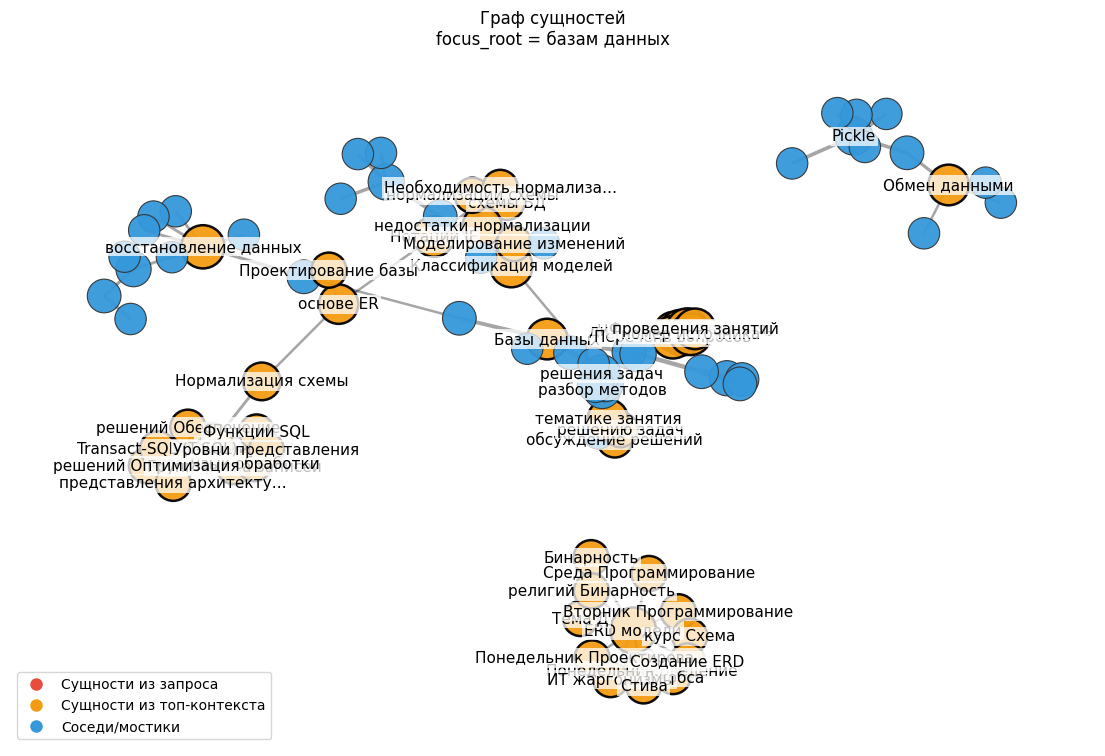

Query entities: ['базам данных']
Context entities (filtered): ['Нотации IE', 'Базы данных', 'восстановление данных', 'ERD модели', 'Обмен данными', 'Бинарность', 'схемы БД', 'обсуждение решений', 'Понедельник Введение', 'Классификация моделей', '- SQL', 'Вторник Основы', 'сущность индексов', 'решению задач', 'форме главы', 'Структура отношения', 'Перечень', 'Термины', 'Наименование тем', 'Среда', 'ИТ -', 'недостатки нормализации', 'Схема компоновки', 'Бинарность бога', 'Моделирование изменений']
Backbone nodes=89, edges=104, components=3


In [25]:
q = "А какие темы охватывают дисциплины по базам данных?"
out = rag.answer(q, top_k=10, multi_hop=True, audience="auto")

viz = visualize_entity_graph(
    rag,
    query=q,
    contexts=out["contexts"],
    min_edge_weight=2.0,
    backbone_extra_edges=18,
    label_top_n=12,
    focus_only=True
)